# Overnight Sweeps of Implanted CaF2
It has not been annealed... yet

Looking for satellite peaks

## Drivers and Hardware

In [1]:
## General purpose
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.axes as axes
import scipy as sp
import scipy.fft
import drivers.spectroscopyHelpers as sh
import drivers3.laserHelpers as lh
import scipy.optimize as spo
import os
import time
import datetime
import scipy.signal
import matplotlib.colors as cls
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import importlib
import pprint
from tqdm import tqdm
import glob
import re
import scipy.stats

In [ ]:
#drivers
import qcodes as qc

## Equipment
### Laser - 
from toptica.lasersdk.dlcpro.v2_2_0 import DLCpro, NetworkConnection  
from drivers.dlccontrol import dlccontrol as ctrl
import drivers3.laserHelpers as lhzz
### Wavemeter
from qil_WS6wavemeter import TCP_Wavemeter
### Swabian
import TimeTagger


import qcodes.instrument_drivers.tektronix.Keithley_6500 as dmm6500
from qcodes.instrument_drivers.rigol import DP832
from qcodes.instrument_drivers.stahl import Stahl
from qcodes.instrument_drivers.american_magnetics.AMI430_visa import AMI430 
#this gets the VISA AMY driver

# Rigol
from qil_Rigol.rigol import cRigol
from qil_Rigol.rigol import DS1202

import moku

import drivers.spectroscopyHelpers as sh
import drivers.pulse_sequence as beeps
import drivers.proHelpers as proHelp

# For Bluey
import json 
import requests

## For the Moku Pro
from moku.instruments import ArbitraryWaveformGenerator

## Laser Stuff

In [2]:
###### LASER #########
laserIP = '10.196.50.22'
# lh.turn_laser_on(laserIP)

###### WM #########
try:
    wm = TCP_Wavemeter.cWS6WavemeterClient(host='qil-wario')
    print("Wavemeter frequency: ", wm.readFrequency())
except KeyError:
    print("Key error returned - wavemeter probably not seeing enough light.")

def get_laser_frequency(numAvgs):
    currentFreq = 0
    for i in range(numAvgs):
        currentFreq +=   wm.readFrequency()
        #print(currentFreq)
        time.sleep(1e-7)

    currentFreq = currentFreq/numAvgs
    return currentFreq

def get_long_laser_frequency(numPoints):
    freqs = np.empty(numPoints)
    for i in range(len(freqs)):
        freqs[i] = get_laser_frequency(1)
    
    return freqs*1e12 #take out of THz

Importing Functions
Wavemeter frequency:  197.0506134033203


## Other Instruments
Detectors et al

In [3]:
## Stahl
stahl = Stahl("stahl-9", "ASRL4")       
detectorOut = stahl.channel8

c:\Users\Mario\.conda\envs\qcodes_env\lib\site-packages\qcodes\instrument\instrument_base.py:642: UserWarning: Changed stahl-9 to stahl_9 for instrument identifier
  warnings.warn(f"Changed {name} to {new_name} for instrument identifier")
[stahl_9(Stahl)] Could not connect at ASRL4
Traceback (most recent call last):
  File "c:\Users\Mario\.conda\envs\qcodes_env\lib\site-packages\qcodes\instrument\visa.py", line 215, in _connect_and_handle_error
    visa_handle, visabackend, resource_manager = self._open_resource(
  File "c:\Users\Mario\.conda\envs\qcodes_env\lib\site-packages\qcodes\instrument\visa.py", line 243, in _open_resource
    resource = resource_manager.open_resource(address)
  File "c:\Users\Mario\.conda\envs\qcodes_env\lib\site-packages\pyvisa\highlevel.py", line 3304, in open_resource
    res.open(access_mode, open_timeout)
  File "c:\Users\Mario\.conda\envs\qcodes_env\lib\site-packages\pyvisa\resources\resource.py", line 297, in open
    self.session, status = self._resour

VisaIOError: VI_ERROR_RSRC_BUSY (-1073807246): The resource is valid, but VISA cannot currently access it.

In [6]:
## Keithley
dmm = dmm6500.Keithley_6500('dmm','TCPIP0::10.196.50.27::INSTR')

Connected to: KEITHLEY INSTRUMENTS DMM6500 (serial:04658928, firmware:1.7.14j) in 0.02s


In [ ]:
## Moku AWG
mokuIP = '10.196.50.45'
awg = ArbitraryWaveformGenerator(mokuIP, force_connect=True, persist_state=True, read_timeout=30)

In [17]:
## Swabian Time Tagger
tt = TimeTagger.createTimeTagger()
# TT params:
# 10 us bins
# 15 e3 bins
# trigger height 0.033 V


# Setting up time-tagger histogram channel
ps = 1e12 # [ps/s] - picoseconds per second. As usual I try to frame variables in SI units, but Swabian is in picoseconds. :((

binwidth = 500e-9 * ps  # 0.1 ms, in picoseconds - [s] * [ps/s]
n_bins = 80 # number of bins
hist = TimeTagger.Histogram(tagger=tt, start_channel=2, click_channel=1, binwidth=binwidth, n_bins = n_bins)
tt.setTriggerLevel(2, 0.25)      # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setTriggerLevel(1, 0.03)      # click channel trigger level = 33 mV
tt.setDeadtime(1,30e-9 * ps)


def getHistDataWrapped(intTime=0.1):
    ps = 1e12                               # ps/s
    hist.startFor(intTime*ps, clear=True)   # run the histogram measurment for 5 seconds then get data. Clear removes old data before starting the measurement
    hist.waitUntilFinished()                # pause execution of python code until the measurement finished flag is true 
    data = hist.getData()                   # get data, of course 
    times = hist.getIndex()/ps              # time [s]
    return data, times

def test_histogram(intTime = 1, plot = 'lin'):
    data, times = getHistDataWrapped(intTime)
    laserFrequency = np.round(get_laser_frequency(20),6)
    if plot =='log':
        plt.semilogy(times*1e3, data, label= "Total Counts: " + str(sum(data)))              
    else:    
        plt.plot(times*1e3, data, label= "Total Counts: " + str(sum(data)))              
    plt.xlabel("Time (ms)")
    plt.title(str(laserFrequency) + ' THz, '+ str(intTime)+' s integration')              
    plt.legend()

In [ ]:
def reset_detector(highLevel = None, sleepTime = 0.5):
    if highLevel == None:
        highLevel = detectorOut.voltage()

    detectorOut.voltage(0)
    time.sleep(sleepTime)
    detectorOut.voltage(highLevel)
    return highLevel


def set_detector(highLevel):
    detectorOut.voltage(highLevel)
    return highLevel

def increment_bias(increment):
    currentBias = detectorOut.voltage()
    val = set_detector(round(currentBias+increment, 5))
    return val

def reset_amp(setVoltage = -1):
    if setVoltage == -1:
        setVoltage = psu.ch3.voltage()
    psu.ch3.set_voltage(0)
    time.sleep(1)
    psu.ch3.set_voltage(setVoltage)
    return setVoltage

def set_amp(setVoltage = 2):
    psu.ch3.set_voltage(setVoltage)
    return setVoltage

def get_detector_current(multimeter = dmm):
    i_now = multimeter._read_next_value()
    return i_now

## Plotting Helpers

In [2]:
# Tim's Handy Plotting Helpers
def cm2inch(*tupl):
    inch = 2.54
    if isinstance(tupl[0], tuple):
        return tuple(i/inch for i in tupl[0])
    else:
        return tuple(i/inch for i in tupl)

def adjust_by_db(inputValue, gain):
    outputValue = inputValue * (10** (gain/10))
    return outputValue 

def setfontsize(size, ax):
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontsize(size)
    return

def sparse_sweep_pos(start, end):
    '''Generate [1,2,5]*10^n spaced points between start and end (must both be >0 and start<=end).'''
    points = []
    abs_min = min(start, end) if min(start, end) > 0 else 1
    abs_max = max(start, end) if max(start, end) > 0 else 1
    pmin = int(np.floor(np.log10(abs_min)))
    pmax = int(np.ceil(np.log10(abs_max)))
    for p in range(pmin, pmax+1):
        for base in [1,2,5]:
            v = base * 10**p
            if start <= v <= end:
                points.append(v)
    if start not in points:
        points.append(start)
    if end not in points:
        points.append(end)
    return sorted(set(points))


def sweep_points(sweepStart, sweepEnd, sweepInc, rounding=6):
    """
    Point sweeper. Useful for sweeping points.
    Args:
        sweepStart (any): generally an int or a float. the point at which your sweep starts
        sweepEnd (_type_): generally an int or a float. the point at which your sweep ends
        sweepInc (_type_): generally an int or a float. the increment between points. use special argument "sparse" for it to generate 1,2,5 flavoured sweeps
        rounding (int, optional): integer number of digits to round the output to.  Defaults to 6.

    Returns:
        points (array): an array of the "sweep points" that you ask for. 
    """
    sweepStart = float(sweepStart)
    sweepEnd = float(sweepEnd)
    if sweepInc == 'sparse':
        points = []
        # Negative to negative
        if sweepStart < 0 and sweepEnd < 0:
            pos_points = sparse_sweep_pos(abs(sweepEnd), abs(sweepStart))
            points = [-x for x in pos_points[::-1]]
        # Positive to positive
        elif sweepStart > 0 and sweepEnd > 0:
            points = sparse_sweep_pos(min(sweepStart, sweepEnd), max(sweepStart, sweepEnd))
            if sweepStart > sweepEnd:
                points = points[::-1]
        # Crosses zero
        elif (sweepStart < 0 < sweepEnd) or (sweepEnd < 0 < sweepStart):
            neg_points = sparse_sweep_pos(1, abs(min(sweepStart, sweepEnd)))
            neg_points = [-x for x in neg_points[::-1] if -x >= min(sweepStart, sweepEnd)]
            pos_points = sparse_sweep_pos(1, max(sweepStart, sweepEnd))
            pos_points = [x for x in pos_points if x <= max(sweepStart, sweepEnd)]
            points = (neg_points + [0.0] + pos_points) if sweepStart < sweepEnd else (pos_points[::-1] + [0.0] + neg_points[::-1])
        # Starts or ends at zero
        elif sweepStart == 0 or sweepEnd == 0:
            if sweepStart == 0 and sweepEnd != 0:
                if sweepEnd > 0:
                    points = [0.0] + sparse_sweep_pos(1, sweepEnd)
                else:
                    points = [0.0] + [-x for x in sparse_sweep_pos(1, abs(sweepEnd))[::-1]]
            elif sweepEnd == 0 and sweepStart != 0:
                if sweepStart > 0:
                    points = sparse_sweep_pos(1, sweepStart)[::-1] + [0.0]
                else:
                    points = [-x for x in sparse_sweep_pos(1, abs(sweepStart))] + [0.0]
            else:
                points = [0.0]
        points = np.round(points, rounding)
        points = np.array(points)
    else:
        sweepInc = float(sweepInc)
        if sweepStart > sweepEnd:
            points = np.arange(sweepStart, sweepEnd - sweepInc, -sweepInc)
        else:
            points = np.arange(sweepStart, sweepEnd + sweepInc, sweepInc)
    return points

def plot_county_echo(subFolderData,  echoCentre = 3,  echoLength = 5, trimStart = 0, normalize = True, trimEnd = 1e3, plotdiffs = False):
    # other arguments: field, frequency, 
    # get dem files
    files = os.listdir(subFolderData)
    files = [file for file in files if '.csv' in file]

    # empty counts and pilengths
    counts = np.zeros(len(files))
    taus = np.zeros(len(files))

    # get counts and taus and now populate
    for i, file in enumerate(files):
        fileRead = np.loadtxt(subFolderData + file, delimiter=",")
        times, data = fileRead[0], fileRead[1]
        timeStart = (echoCentre-(0.5*echoLength)) * 1e-6
        timeEnd = (echoCentre + 0.5*echoLength) * 1e-6
        lastTime = times[-1]
        # counts[i] = np.sum(data[(times>timeStart) & (times<timeEnd)]) - np.sum(data[(times>timeEnd) & (times<(timeEnd + echoLength*1e-6))])

        echoCounts = np.sum(data[(times>timeStart) & (times<timeEnd)])
        backgroundTimeCorrection = (lastTime - timeEnd) / (timeEnd-timeStart)
        backgroundCounts = (np.sum(data[(times>timeEnd) & (times<lastTime)])) / backgroundTimeCorrection
        counts[i]  = echoCounts - backgroundCounts
        print(counts[i])

    field = (files[0].split("_")[-1].split()[0])
    frequency = (files[0].split("_")[-2].split()[0])

    filename = "Echo Experiment, Frequency"+ frequency + " THz, Field "+ field + " mT"

    if normalize:
        counts /= np.max(counts)


    fig, ax = plt.subplots(figsize = [6,4])
    if plotdiffs: 
        ax.plot(taus[(taus>trimStart) & (taus <trimEnd)],(counts[(taus>trimStart) & (taus < trimEnd)]), '.', label= "Total Counts: " + str(sum(data)))
        ax.hlines(0,xmin=np.min(taus[(taus>trimStart) & (taus <trimEnd)]), xmax = np.max(taus[(taus>trimStart) & (taus <trimEnd)]), linestyles="dashed", colors='k')
        #ax.set_ylim([-5, 50])
        ax.set_xlabel("Delay time ($\mu$s)")
        ax.set_ylabel("Counts - background")
        ax.set_title(subFolderData+ filename + ' diffs')

    else:
        ax.plot(taus[(taus>trimStart) & (taus <trimEnd)],np.log(counts[(taus>trimStart) & (taus < trimEnd)]), '.', label= "Total Counts: " + str(sum(data)))
        ax.set_xlabel("Delay time ($\mu$s)")
        ax.set_ylabel("Log of Photon Counts (number)")
        ax.set_title(subFolderData+ filename)
    
    fig.savefig(pathPlots+filename+".eps")
    fig.savefig(pathPlots+filename+".png")
    fig.savefig(pathPlots+filename+".pdf")

    def plot_fit_county_echo(subFolderData, linear = True, echoCentre =3, echoLength =5, trimStart = 3, trimEnd = 17, mims = True, plotFits = True,plotFullData = False,plotEnd = 200, saving = False):
        # other arguments: field, frequency, 
        # get dem files
        files = os.listdir(subFolderData)
        files = [file for file in files if '.csv' in file]

        # empty counts and pilengths
        counts = np.zeros(len(files))
        taus = np.zeros(len(files))

        # get counts and taus and now populate
        for i, file in enumerate(files):
            fileRead = np.loadtxt(subFolderData + file, delimiter=",")
            times, data = fileRead[0], fileRead[1]
            timeStart =( echoCentre- (0.5*echoLength)) * 1e-6
            #timeEnd = 7.5e-6
            timeEnd = timeStart + echoLength*1e-6
            counts[i] = np.sum(data[(times>timeStart) & (times<timeEnd)]) - np.sum(data[(times>timeEnd) & (times<(timeEnd + echoLength*1e-6))])
            
            taus[i] = float(file.split("_")[1].split()[1])


        indices = np.argsort(taus)
        taus = taus[indices]
        counts = counts[indices]

        tausTrimmed = taus[(taus > trimStart) & (taus< trimEnd)]
        countsTrimmed = counts[(taus > trimStart) & (taus< trimEnd)]
        countsTrimmed = countsTrimmed / np.max(countsTrimmed)


        try:
            if linear:

                exponential =   lambda tau, I_0, b, c,: c + I_0*np.exp**(-4*tau/b)
                mims_function = lambda tau, I_0, b, c, x :c + I_0* np.exp**(-((4*tau /b)**x))

                popt, pcov = spo.curve_fit(exponential, tausTrimmed, countsTrimmed, p0=(2,2,2))
                pvars = np.sqrt(np.diag(pcov))
                a,b,c = popt
                # print(c)

                T2 = str(np.round(b,1))
                T2var = str(np.round(pvars[1], 1))
                countsToPlot = np.log(countsTrimmed - c)

                if mims:
                    popt, pcov = spo.curve_fit(mims_function, tausTrimmed, countsTrimmed, p0 = (2,2,1,2))
                    pvars = np.sqrt(np.diag(pcov))

                    a,b,c,d = popt

                    x_m = str(np.round(d,3))


                    Tm = str(np.round(b,3))
                    Tmvar = str(np.round(pvars[1], 1))
            
            else:

                tausTrimmed = tausTrimmed[(countsTrimmed > 0)]
                countsTrimmed = countsTrimmed[(countsTrimmed > 0)]
                
                countsTrimmed = np.log(countsTrimmed)

                # debug plot
                # plt.figure()
                # plt.plot(tausTrimmed, countsTrimmed, ".")
                # plt.xlabel(r'Wait time $\tau$, $\mu s$')
                # plt.ylabel(r'log counts')
                
                exponential =   lambda tau, I_0, b, :   I_0 - 4*tau/b
                mims_function = lambda tau, I_0, b,  x :  I_0 - (4*tau/b)**x
                bi_exponential = lambda tau1, tau2, I_01, I_02, b1, b2: (I_01 - 4* tau1/b1) + (I_02 - 4*tau2/b2)
                
                #popt, pcov = spo.curve_fit(exponential, tausTrimmed, countsTrimmed, p0=(0.5,20))
                # pvars = np.sqrt(np.diag(pcov))
                # exp_a,exp_b = popt
                # print(popt)
                # T2 = str(np.round(exp_b,1))
                # T2var = str(np.round(pvars[1], 1))

                slope, intercept, r, p, se = scipy.stats.linregress(tausTrimmed,countsTrimmed)
                T2 = str(np.round((-4 / slope), 2))
                T2var = str(np.round(se,3))
        
                countsToPlot = countsTrimmed

                if mims:
                    lowerBounds = [0, 0, 1]
                    upperBounds = [np.inf, np.inf, np.inf]
                    popt, pcov = spo.curve_fit(mims_function, tausTrimmed, countsTrimmed, p0 = (0.5,10,1),bounds=(lowerBounds, upperBounds))
                    pvars = np.sqrt(np.diag(pcov))
                    a,b, d = popt
                    #print(popt)
                    x_m = str(np.round(d,2))

                    Tm = str(np.round(b,2))
                    Tmvar = str(np.round(pvars[1], 2))


            field = (files[0].split("_")[-1].split()[0])
            frequency = (files[0].split("_")[-2].split()[0])
            angle = subFolderData.split(" ")[-2].split(" ")[0]

            filename = "Hahn Echo Experiment, Frequency " + frequency + " THz, Field "+ field + " mT"

            fig, ax = plt.subplots()
            fig.set_size_inches(7,5)

            #ax.plot(taus,countsToPlot, '.', label = r"$T_2 ~ ($" + T2 + r"$\,\pm\,$" + T2var + r"$)\mu$s")
            ax.plot(tausTrimmed,countsToPlot, '.')
            if plotFits:
                # ax.plot(tausTrimmed,(exponential(tausTrimmed, exp_a, exp_b)), "--r", label=r"$T_2 = ($" + T2 + r"$\,\pm\,$" + T2var + r"$)\mu$s")
                ax.plot(tausTrimmed, tausTrimmed*slope + intercept, "--r", label=r"$T_2 = ($" + str(T2) + r"$\,\pm\,$" + str(T2var) + r"$)\mu$s")
            if mims:
                ax.plot(tausTrimmed,(mims_function(tausTrimmed, a, b, d)), "--k", label=r"$T_{m} = ($" + Tm + r"$\,\pm\,$" + Tmvar + r"$)\mu$s, x = " +x_m)
            if plotFullData:
                ax.plot(taus[(taus<plotEnd)], np.log((counts)/np.max(counts))[(taus<plotEnd)],'.', color='C0')

            ax.legend()
            ax.set_xlabel("Delay time ($\mu$s)")
            ax.set_ylabel("Log of Normalised Counts")
            ax.set_title(subFolderData+filename)

        #    ax.set_ylim([0, 1])
            
            if saving ==True:
                fig.savefig(pathPlots+filename+".png")
                fig.savefig(pathPlots+filename+".pdf")

            if mims:
                return T2,T2var, Tm, Tmvar, x_m, field, angle
            else:
                return T2,T2var, 0, 0, 0, field, angle
        except Exception as e:
            print(e)
            field = (files[0].split("_")[-1].split()[0])
            angle = subFolderData.split(" ")[-2].split(" ")[0]

        return 0,0, 0, 0, 0, field, angle

## Experiment Functions

In [20]:
def set_deadcycles(awg, deadCycles, channels):

    # turn on pulse_modulate mode only once
    for channel in channels:
            awg.pulse_modulate(channel, dead_cycles = deadCycles, dead_voltage = 0)
    awg.sync_phase()
    return

def set_up_echo_SNSPD(pi2, pi, tau, period = 0, countFor = 10, switchPreDelay = 3, nPoints = 5000, plotting = False, verbose = False, pi2Off = False, piOff = False):  

    #Args:
    # pi2 - pi/2 pulse length
    # pi -
    # tau - remember HOW TAU IS DEFINED HERE
    # countinghold - basically how long you want the SNSPD to count for
    # predelay - moves the trigger back in time to account for switches taking a moment to ... switch. 
    #            be CAREFUL you might end up in the FID if you make this too long 
    # nPoints - the number of points - this defines the timing resolution with which we make the pulse sequence 

    # default to count for 10 us
    # easter egg tho, to make it so that the count time depends on pi pulse time
    if countFor == -1:
        countFor = 4*pi

    switchTimings = [pi2, tau, pi, tau+pi2 + countFor]
    aomTimings = [pi2, tau, pi, tau+pi2 + countFor]
    ttlTimings = [pi2+tau+pi+tau+pi2/2, pi2/2 + countFor]  # 1us boop
    totalTime = sum(switchTimings)
    snspdTiming = [totalTime-(countFor+switchPreDelay), countFor+switchPreDelay] #start counting on the SNSPD about two pi-pulse-lengths before the echo comes out. you work out the rest. 
    
    if pi2Off:
        switchTimings = [pi2 + tau, pi, tau+pi2 + countFor]
        aomTimings = [pi2 + tau, pi, tau+pi2 + countFor]
            
    if piOff:
        switchTimings = [pi2, tau + pi + tau+pi2 + countFor]
        aomTimings = [pi2, tau + pi + tau+pi2 + countFor]

    if pi2Off & piOff:
        switchTimings = [pi2+ tau + pi + tau+pi2 + countFor]
        aomTimings = [pi2+ tau + pi + tau+pi2 + countFor]

    if verbose == True:
        print('calculated timings')
    
    aoms = beeps.pulse_sequence(aomTimings,startHigh=True, highVoltage=5, numPoints = nPoints, period=period)
    switch1 = beeps.pulse_sequence(switchTimings, startHigh=True, highVoltage=5, numPoints = nPoints, period =period)
    echoTTL = beeps.pulse_sequence(ttlTimings, startHigh = False, numPoints = nPoints, period = period)
    snspdBias = beeps.pulse_sequence(snspdTiming, highVoltage=3.5, startHigh = False, numPoints= nPoints, period = period)
    
    if piOff:
        aoms = beeps.pulse_sequence(aomTimings,startHigh=True, highVoltage=5, numPoints = nPoints, period=period)
        switch1 = beeps.pulse_sequence(switchTimings, startHigh=True, highVoltage=5, numPoints = nPoints, period =period)

    if pi2Off:
        aoms = beeps.pulse_sequence(aomTimings,startHigh=False, highVoltage=5, numPoints = nPoints, period=period)
        switch1 = beeps.pulse_sequence(switchTimings, startHigh=False, highVoltage=5, numPoints = nPoints, period =period)

    if verbose == True:
        print('generated sequences')

    packet = [aoms , switch1, echoTTL,  snspdBias]
    proChannels = [1,2,3,4]

    if not(plotting):
        proHelp.tell_awg(packet, proChannels, awg)
        if verbose ==True:
            print('told awg')

    if plotting:
        plt.plot(aoms.times, aoms.lookupTable)
        plt.plot(switch1.times, switch1.lookupTable)
        # plt.plot(switch2.times, switch2.lookupTable, "--")
        # plt.plot(voa.times, voa.lookupTable)
        plt.plot(echoTTL.times, echoTTL.lookupTable)
        plt.plot(snspdBias.times,snspdBias.lookupTable)
        plt.legend(("aoms",
                    "switches", 
                    # "switch 2", 
                    # "VOA", 
                    "echo TTL",
                    "snspd"))
    return

def do_echo_snspd(pi2, tau, pi, frequency, pathData, pathPlots, tt, pi2Off = False, piOff = False, period = 0, countFor = 10, switchPreDelay = 3, fld =0, angle=0, bias = -0.8, intTime = 0.1, indVar="tau"):
    """
    Take a single trace using the given waveform parameters. Further updates needed to make this less Hahn-echo specific. 

    Parameters:
    1. pi2 : float
        length of first pulse, [us]

    2. tau : float
        length of first wait, [us]

    2. pi : float
        length of second pulse, [us]

    2. voaVoltage : float
        Voltage applied to the VOA
    
    3. fld : float
        Magnetic field, in Tesla.
        
    4. angle: float
        magnetic field angle in the x-z-plane IN DEGREES
    
    3. frequency : float
        Current wavemeter frequency, saved in the filename

    4. pathData : str

    5. pathPlots : str

    5. rigol : visa oscilloscope object

    6. channels : list, (default [1,2])

        FIRST CHANNEL IS THE DATA CHANNEL ALWAYS

    7. numShots : int, (default 1)
        number of traces to take
    
    8. getSwitchTrace : bool, (default False)
        if True, take a trace of the switch data from the 2nd channel given. Dynamically adjusts rigol timebase in order to do this. 
    
    Returns
    ---------
    """
    # save the experimental parameters
    expParams = locals()
    indVarValue = expParams[indVar]

    
    # np.save("experiment_parameters.npy", expParams, allow_pickle=True)
    ## to read this file type: expParams = np.load(filename, allow_pickle=True).item()
    ## .item() method turns the output from an array containing a single dict to just the dict itself
    # proHelp.tell_awg(packet, proChannels, awg)

    # Commented out the above, added the below, NB relies on set_up_echo to work and know what the correct moku channels are.
    # NB that set_up_echo doesn't use the "packet" defined above, cos it's doing that itself. 
    
    set_up_echo_SNSPD(pi2, pi , tau, period, countFor, switchPreDelay, pi2Off = pi2Off, piOff = piOff)
    #TODO Add predelay, other SSPD params to this

    reset_detector(bias, sleepTime = 0.1)
    
    data, times = getHistDataWrapped(intTime)
    dataAndTime = np.array([times, data])

    # save data
    now = datetime.datetime.now()
    filename =  now.strftime("%Y-%m-%d %H-%M-%S") + "_" + indVar +" "+ str(round(indVarValue,5))+"_"+ str(round(frequency,5))+" THz" + "_"+ str(round(fld*1000))+" mT" # old one
    np.savetxt(pathData+filename + ".csv", dataAndTime, delimiter=",")

    # plot data
    fig, ax = plt.subplots()
    ax.plot(times*1e3, data, label= "Total Counts: " + str(sum(data)))
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel(f"Counts ({intTime} s integration)")
    ax.set_title(str(np.round(frequency, 5)) +" GHz")
    plt.legend()

    fig.savefig(pathPlots + filename + ".png")
    fig.savefig(pathPlots + filename + ".pdf")
    plt.close(fig)

def set_up_ramsey_SNSPD(pi2, tau, w, period = 0, do3pi2 = False, countFor = None, switchPreDelay = 1, nPoints = 5000, plotting = False, verbose = False, pi2Off = False, piOff = False):  

    #Args:
    # pi2 - pi/2 pulse length
    # pi -
    # tau - remember HOW TAU IS DEFINED HERE
    # countinghold - basically how long you want the SNSPD to count for
    # predelay - moves the trigger back in time to account for switches taking a moment to ... switch. 
    #            be CAREFUL you might end up in the FID if you make this too long 
    # nPoints - the number of points - this defines the timing resolution with which we make the pulse sequence 

    # default to count for 10 us
    # easter egg tho, to make it so that the count time depends on pi pulse time
    if countFor ==None:
        countFor = 4*pi2

   # Hahn:
   # switchTimings = [pi2, tau, pi, tau+pi2 + countFor]

    switchTimings = [pi2, tau, pi2, w, pi2, tau + pi2 + countFor]
    aomTimings =    [pi2, tau, pi2, w, pi2, tau + pi2 + countFor]
    ttlTimings =    [pi2 + tau + pi2 + w + pi2 + tau + pi2/2,  pi2/2 + countFor]  # 1us boop
    #totalTime = sum(switchTimings)
    snspdTiming = [pi2 + tau + pi2 + w + pi2 + tau - switchPreDelay, countFor + pi2 +switchPreDelay] #start counting on the SNSPD about two pi-pulse-lengths before the echo comes out. you work out the rest. 
    
    if pi2Off:
        switchTimings = [pi2 + tau, w, tau+pi2 + countFor]
        aomTimings = [pi2 + tau, w, tau+pi2 + countFor]
    
    if do3pi2 == True:
        switchTimings = [pi2, tau, pi2, w,pi2*3, 2*tau + pi2 + countFor]
        aomTimings =    [pi2, tau, pi2, w,pi2*3, 2*tau + pi2 + countFor]
            
    if verbose == True:
        print('calculated timings')
    
    aoms = beeps.pulse_sequence(aomTimings,startHigh=True, highVoltage=5, numPoints = nPoints, period=period)
    switch1 = beeps.pulse_sequence(switchTimings, startHigh=True, highVoltage=5, numPoints = nPoints, period =period)
    echoTTL = beeps.pulse_sequence(ttlTimings, startHigh = False, numPoints = nPoints, period = period)
    snspdBias = beeps.pulse_sequence(snspdTiming, highVoltage=3.5, startHigh = False, numPoints= nPoints, period = period)

    if pi2Off:
        aoms = beeps.pulse_sequence(aomTimings,startHigh=False, highVoltage=5, numPoints = nPoints, period=period)
        switch1 = beeps.pulse_sequence(switchTimings, startHigh=False, highVoltage=5, numPoints = nPoints, period =period)


    
    if verbose == True:
        print('generated sequences')

    packet = [aoms , switch1, echoTTL,  snspdBias]
    proChannels = [1,2,3,4]

    if not(plotting):
        proHelp.tell_awg(packet, proChannels, awg)
        if verbose ==True:
            print('told awg')

    if plotting:
        plt.plot(aoms.times, aoms.lookupTable)
        plt.plot(switch1.times, switch1.lookupTable)
        # plt.plot(switch2.times, switch2.lookupTable, "--")
        # plt.plot(voa.times, voa.lookupTable)
        plt.plot(echoTTL.times, echoTTL.lookupTable)
        plt.plot(snspdBias.times,snspdBias.lookupTable)
        plt.legend(("aoms",
                    "switches", 
                    # "switch 2", 
                    # "VOA", 
                    "echo TTL",
                    "snspd"))
    return

def do_ramsey_SNSPD(pi2, tau, w, frequency, pathData, pathPlots, tt, do3pi2=False, period = 0, countFor = 10, switchPreDelay = 3, nPoints=5000, fld =0, angle=0, bias = -0.8, intTime = 0.1, indVar1="tau", indVar2="w"):

    # save the experimental parameters
    expParams = locals()
    indVar1Value = expParams[indVar1]
    indVar2Value = expParams[indVar2]

    
    # np.save("experiment_parameters.npy", expParams, allow_pickle=True)
    ## to read this file type: expParams = np.load(filename, allow_pickle=True).item()
    ## .item() method turns the output from an array containing a single dict to just the dict itself
    # proHelp.tell_awg(packet, proChannels, awg)

    # Commented out the above, added the below, NB relies on set_up_echo to work and know what the correct moku channels are.
    # NB that set_up_echo doesn't use the "packet" defined above, cos it's doing that itself. 

    set_up_ramsey_SNSPD(pi2=pi2, tau=tau, w=w, period = period, do3pi2 = do3pi2, countFor = countFor, switchPreDelay = switchPreDelay, nPoints = nPoints, plotting = False, verbose = False)
    reset_detector(bias, sleepTime = 0.2)
    
    data, times = getHistDataWrapped(intTime)
    dataAndTime = np.array([times, data])

    # save data
    now = datetime.datetime.now()
    filename =  now.strftime("%Y-%m-%d %H-%M-%S") + "_" + indVar1 +" "+ str(round(indVar1Value,5))+ "_" + indVar2 +" "+ str(round(indVar2Value,5))+"_"+ str(round(frequency,5))+" THz" + "_"+ str(round(fld*1000))+" mT" # old one
    np.savetxt(pathData+filename + ".csv", dataAndTime, delimiter=",")

    # plot data
    fig, ax = plt.subplots()
    ax.plot(times*1e3, data, label= "Total Counts: " + str(sum(data)))
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel(f"Counts ({intTime} s integration)")
    ax.set_title(str(np.round(frequency, 5)) +" GHz")
    plt.legend()

    fig.savefig(pathPlots + filename + ".png")
    fig.savefig(pathPlots + filename + ".pdf")
    plt.close(fig)

def all_on(snspd = False, plotting = False):  

    #Args:
    # pi2 - pi/2 pulse length
    # pi -
    # tau - remember HOW TAU IS DEFINED HERE
    # countinghold - basically how long you want the SNSPD to count for
    # predelay - moves the trigger back in time to account for switches taking a moment to ... switch. 
    #            be CAREFUL you might end up in the FID if you make this too long 
    # nPoints - the number of points - this defines the timing resolution with which we make the pulse sequence 

    # default to count for 10 us
    # easter egg tho, to make it so that the count time depends on pi pulse time

    switchTimings = [100]
    ttlTimings = [100]  # 1us boop
    totalTime = sum(switchTimings)

    snspdTiming = [100] #start counting on the SNSPD about two pi-pulse-lengths before the echo comes out. you work out the rest. 

    nPoints = 5000

    AOMs = beeps.pulse_sequence(switchTimings, highVoltage=5,startHigh=False, numPoints = nPoints)
    AOMs.lookupTable += 5

    switches = beeps.pulse_sequence(switchTimings, highVoltage=5,startHigh=False, numPoints = nPoints)
    switches.lookupTable += 5

    echoTTL = beeps.pulse_sequence(ttlTimings, startHigh = False, numPoints = nPoints)
    snspdBias = beeps.pulse_sequence(snspdTiming, highVoltage=3, startHigh = False, numPoints= nPoints)
    
    if snspd:
        snspdBias.lookupTable+=3

    packet = [AOMs, switches, echoTTL, snspdBias]
    proChannels = [1,2,3,4]

    if not(plotting):
        proHelp.tell_awg(packet, proChannels, awg)
        for channel in proChannels:
            awg.disable_modulation(channel)
        # TODO add set_deadcycles to AWG helpers
        # and add a condition for set_deadcycles where it makes 
        # sense of an argument of zero
        # set_deadcycles(awg, 0, channels)

    if plotting:
        plt.plot(AOMs.times, AOMs.lookupTable)
        plt.plot(switches.times, switches.lookupTable)
        
        #plt.plot(switch2.times, switch2.lookupTable, "--")
        # plt.plot(voa.times, voa.lookupTable)
        plt.plot(echoTTL.times, echoTTL.lookupTable)
        plt.plot(snspdBias.times,snspdBias.lookupTable)
        plt.legend(("AOMs",
                    "switches", 
                    # "switch 2", 
                    # "VOA", 
                    "echo TTL",
                    "snspd"))
    return

## Tuning Collection Parameters

In [25]:
reset_detector(-0.8)

-0.8

In [27]:
currentCurrent = get_detector_current()
print(currentCurrent)

4.761471e-06


In [31]:
# Sets excitation/collection duty cycle by switching with timed square wave
set_deadcycles(awg, 2, [1,2,3,4])

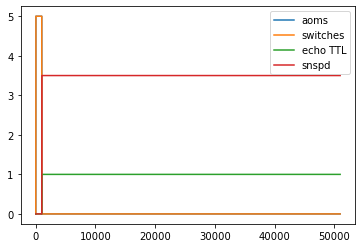

In [39]:
set_up_echo_SNSPD(0,1e3,1, countFor=50e3, switchPreDelay=0, plotting=True)
set_up_echo_SNSPD(0,1e3,1, countFor=50e3, switchPreDelay=0, plotting=False)

set_deadcycles(awg, 2, channels=[1,2,3,4])

In [38]:
# Set wavelengths
wavelengths = np.array([1521.3308401, 1518.08, 1514.70, 1512.10873212, 1508.2256587 , 1506.976, 1504.59024])
wavelengths

array([1521.3308401 , 1518.08      , 1514.7       , 1512.10873212,
       1508.2256587 , 1506.976     , 1504.59024   ])

In [41]:
lhzz.set_laser_wavelength(laserIP, 1514.70)

Wavelength now set to 1514.7


In [63]:
reset_detector(-0.9)

-0.9

In [53]:
TimeTagger.freeTimeTagger(tt)

True

In [64]:
tt = TimeTagger.createTimeTagger()
# TT params:
# 500 us bins
# 200 bins
# trigger height 0.05 V
# Setting up time-tagger histogram channel
ps = 1e12 # [ps/s] - picoseconds per second. As usual I try to frame variables in SI units, but Swabian is in picoseconds. :((

binwidth = 500e-6 * ps  # 0.1 ms, in picoseconds - [s] * [ps/s]
n_bins = 200 # number of bins
hist = TimeTagger.Histogram(tagger=tt, start_channel=2, click_channel=1, binwidth=binwidth, n_bins = n_bins)
tt.setTriggerLevel(2, 0.25)      # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setTriggerLevel(1, 0.05)      # click channel trigger level = 33 mV

def getHistDataWrapped(intTime=0.1):
    ps = 1e12                               # ps/s
    hist.startFor(intTime*ps, clear=True)   # run the histogram measurment for 5 seconds then get data. Clear removes old data before starting the measurement
    hist.waitUntilFinished()                # pause execution of python code until the measurement finished flag is true 
    data = hist.getData()                   # get data, of course 
    times = hist.getIndex()/ps              # time [s]
    return data, times

def test_histogram(intTime = 1, plot = 'log'):
    data, times = getHistDataWrapped(intTime)
    if plot =='log':
        plt.semilogy(times*1e3, data, label= "Total Counts: " + str(sum(data)))              
    else:    
        plt.plot(times*1e3, data, label= "Total Counts: " + str(sum(data)))              
    plt.xlabel("Time (ms)")
    plt.legend()

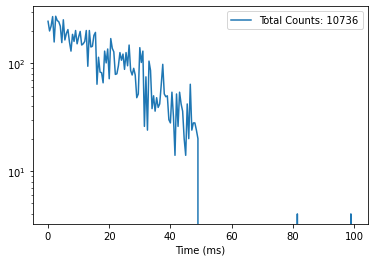

In [65]:
test_histogram(intTime=2, plot='log')

In [77]:
time.strftime('%Y-%m-%d')

'2025-10-24'

# Running an Experiment

In [84]:
try: 
    runID +=1
except NameError:
    runID = 1
runID

1

In [66]:
wavelengths = np.array([1521.3308401, 1518.08, 1514.70, 1512.10873212, 1508.2256587 , 1506.976, 1504.59024])
wavelengths

array([1521.3308401 , 1518.08      , 1514.7       , 1512.10873212,
       1508.2256587 , 1506.976     , 1504.59024   ])

In [87]:
wavelengths_test = [lhzz.get_laser_wavelength(laserIP)]

In [ ]:
for wavelength in tqdm(wavelengths):
    # change laser wavelength
    lhzz.set_laser_wavelength(laserIP, wavelength)

    try: 
        runID +=1
    except NameError:
        runID = 1

    datestring = time.strftime('%Y-%m-%d')

    pathData  = f'data/'+ datestring +f'/confocal/run{runID}/'
    pathPlots = f'plots/'+ datestring +f'/confocal/run{runID}/'
    os.makedirs(pathData, exist_ok=True)
    os.makedirs(pathPlots, exist_ok=True)

    subFolderData = pathData +"/"+str(round(wavelength,5))+"/"    # don't forget ending "/"
    subFolderPlots = pathPlots +"/"+str(round(wavelength,5))+"/"
    os.makedirs(subFolderData, exist_ok=True)
    os.makedirs(subFolderPlots, exist_ok=True)

    scanHalf = 70       # [V]
    n = 140
    lineCentre = 70
    lhzz.set_piezo_center(laserIP, lineCentre)
    time.sleep(0.1)
    centrepV=lhzz.get_piezo_center(laserIP)
    pVs = np.linspace(-scanHalf, scanHalf, n) + centrepV
    intTime= 60
    bias = -0.9


    #change this to an 'enumerate'
    for i, pV in enumerate(tqdm(pVs, desc = 'Piezo Voltage')):
        lhzz.set_piezo_center(laserIP, pV)
        time.sleep(0.1)
        freq = get_laser_frequency(10)       # [THz]
        reset_detector(bias, sleepTime = 0.01)
        data, times = getHistDataWrapped(intTime = intTime)      
        dataAndTime = np.array([times, data])

        # save data
        now = datetime.datetime.now()
        filename = now.strftime("%Y-%m-%d %H-%M-%S") + "_freq_" + str(np.round(freq*1e6)) +"_MHz_pV_" + str(np.round(pV, 1)) + "_V"
        np.savetxt(subFolderData+filename + ".csv", dataAndTime, delimiter=",")

        # plot data
        fig, ax = plt.subplots()
        ax.plot(times*1e3, data)
        ax.set_xlabel("Time (ms)")
        ax.set_ylabel(f"Counts ({int} s integration)")
        ax.set_title(str(np.round(freq*1e3, 3)) +" GHz")
        fig.savefig(subFolderPlots + filename + ".png")
        fig.savefig(subFolderPlots + filename + ".eps")
        plt.close(fig)

        print("Finished pV = ", pV)

  0%|          | 0/7 [00:00<?, ?it/s]

Wavelength now set to 1521.3308401


Finished pV =  0.0


Finished pV =  1.007194244604321


Finished pV =  2.0143884892086277


...

Finished pV =  136.97841726618705


Finished pV =  137.98561151079136


Finished pV =  138.99280575539566


100%|██████████| 7/7 [16:29:42<00:00, 8483.15s/it]  

Finished pV =  140.0


In [ ]:
amc.connect()


In [155]:
TimeTagger.freeTimeTagger(tt)

True

In [159]:
reset_detector(-0.86)

-0.86

In [160]:
stahl.close()

In [161]:
dmm.close()

### thinking about ways to wrangle the data so we can loop through things

In [146]:
subFolderList= os.listdir(subFolderData+'../')
subFolderList

['run3', 'run4', 'run5', 'run6', 'run{runID}']

In [151]:
os.listdir(subFolderData+'../'+subFolderList[1])

['1521.33084']

In [93]:
subFolderData

'data/2025-10-25/confocal/run10//1504.59024/'

# plotting data

In [4]:
subFolderData = 'data/2025-10-25/confocal/run6/'
folders = os.listdir(subFolderData)
wavelength = folders[0]
print('Working at ' +wavelength+ ' nm')

FileNotFoundError: [Errno 2] No such file or directory: 'data/2025-10-25/confocal/run6/'

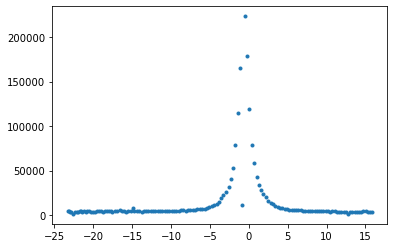

In [14]:
peaks = []
pVs = []
freqs = []
folders = os.listdir(subFolderData)
files = os.listdir(subFolderData+str(folders[0])+'/')
files = [file for file in files if ".csv" in file]

for file in files:
    fileRead = np.loadtxt(subFolderData+str(folders[0]) + '/' + file, delimiter=",")
    times, data = fileRead[0], fileRead[1]
    pV = float(file.split("_")[-2])
    freq = float(file.split("_")[2])

    peaks.append(np.sum(data[1:60]))                                                          # add the peak to the list of peaks            
    pVs.append(pV)                                                              # add the voltage associated with this peak to the list of voltages
    freqs.append(freq)

peaks = np.array(peaks)
pVs = np.array(pVs)
freqs = np.array(freqs)


plt.plot(freqs/1e3 - 197912.5, peaks, '.')


In [11]:
# Spectrum Parameters
scanHalf = 70       # [V]
n = 140
lineCentre = 70
intTime= 60
bias = -0.9

In [ ]:
# directory structure as stored on Mario
folders_1015 = (glob.glob('data/2025-10-15/confocal/*/*'))
folders_1015.remove('data/2025-10-15/confocal\\sample1\\run1')  
folders_1015.remove('data/2025-10-15/confocal\\sample1\\run2')  
folders_1015.remove('data/2025-10-15/confocal\\sample1\\run3')  
folders_1015.remove('data/2025-10-15/confocal\\sample1\\run4')  
folders_1015.remove('data/2025-10-15/confocal\\sample1\\run5')  
folders_1015.remove('data/2025-10-15/confocal\\sample1\\run6')  
folders_1015.remove('data/2025-10-15/confocal\\sample1\\run7')  

folders_1018 = (glob.glob('data/2025-10-18/confocal/*?*/*/*'))

folders_1025 = (glob.glob('data/2025-10-24/confocal/*/*') 
            +
           glob.glob('data/2025-10-25/confocal/*/*'))
folders_1025.remove('data/2025-10-24/confocal\\run3\\1514.6848')  
folders_1025.remove('data/2025-10-24/confocal\\run{runID}\\1514.6848')  


sortedFolders_1015 = sorted(folders_1015,
                       key = lambda x: os.path.basename(x))
sortedFolders_1018 = sorted(folders_1018,
                       key = lambda x: os.path.basename(x))
sortedFolders_1025 = sorted(folders_1025,
                       key = lambda x: os.path.basename(x))

subFolderWavelengths_1015 = [os.path.basename(os.path.normpath(p)) for p in sortedFolders_1015]
subFolderWavelengths_1018 = [os.path.basename(os.path.normpath(p)) for p in sortedFolders_1018]
subFolderWavelengths_1025 = [os.path.basename(os.path.normpath(p)) for p in sortedFolders_1025]

folderDates_1015 = [os.path.normpath(p).split(os.sep)[1] for p in sortedFolders_1015]
folderDates_1018 = [os.path.normpath(p).split(os.sep)[1] for p in sortedFolders_1018]
folderDates_1025 = [os.path.normpath(p).split(os.sep)[1] for p in sortedFolders_1025]

print(subFolderWavelengths_1015)
print(sortedFolders_1015)
print(subFolderWavelengths_1018)
print(sortedFolders_1018)
print(subFolderWavelengths_1025)
print(sortedFolders_1025)

['1504.65', '1508.3', '1512.05', '1514.76', '1518.08', '1521.23']
['data/2025-10-15/confocal/sample 1/1504.65', 'data/2025-10-15/confocal/sample 1/1508.3', 'data/2025-10-15/confocal/sample 1/1512.05', 'data/2025-10-15/confocal/sample 1/1514.76', 'data/2025-10-15/confocal/sample 1/1518.08', 'data/2025-10-15/confocal/sample 1/1521.23']
[]
[]
[]
[]


In [180]:
# Add theoretical location of lines
lines = [199.242e6, # Cubic Z1-Y2
        198.927e6, # Cubic Z1-Y1  
        198.76215e6, # B Z1-Y1
        198.2567e6, # G1 Z1-Y2
        197.913e6, # A Z1-Y2
        197.4686e6, # G1 Z1-Y1
        197.05e6] # A Z1-Y1  

lines_label = [r'Cubic:$Z_1 \rightarrow Y_2$',
               r'Cubic:$Z_1 \rightarrow Y_1$',
               r'B:$Z_1 \rightarrow Y_1$',
               r'G1:$Z_1 \rightarrow Y_2$',
               r'A:$Z_1 \rightarrow Y_2$',
               r'G1:$Z_1 \rightarrow Y_1$',
               r'A:$Z_1 \rightarrow Y_1$']

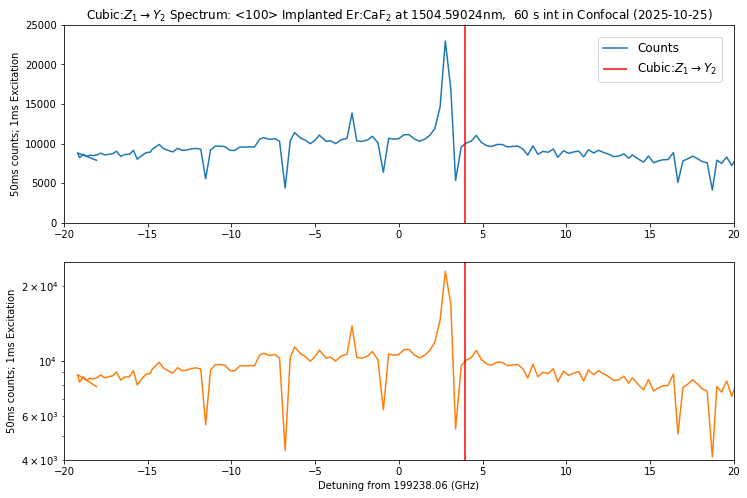

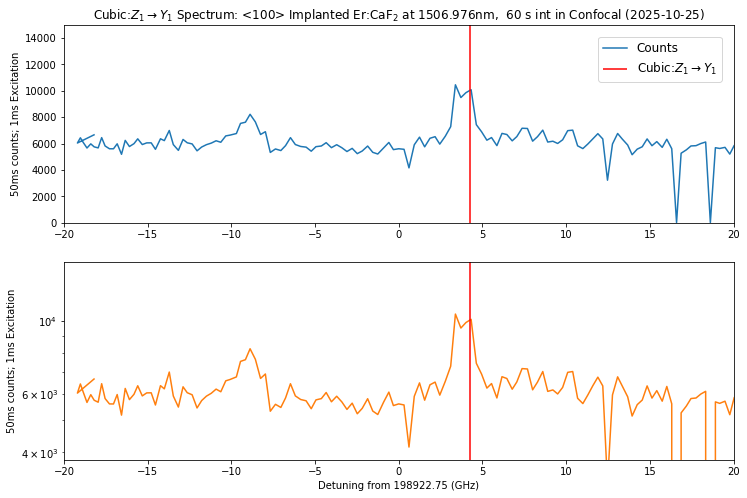

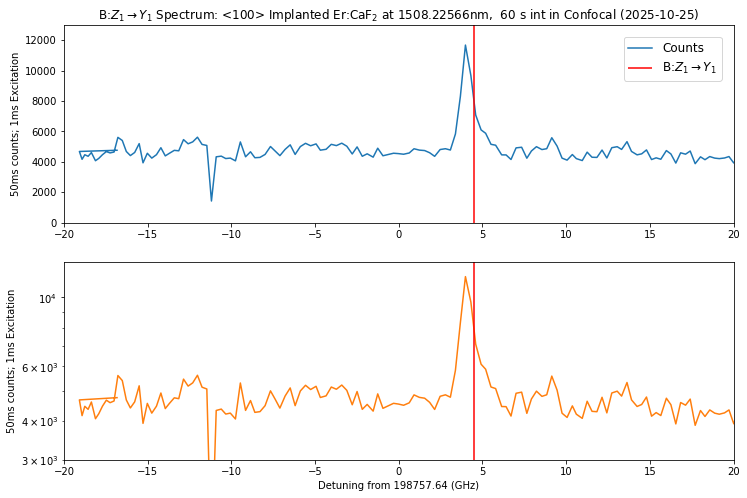

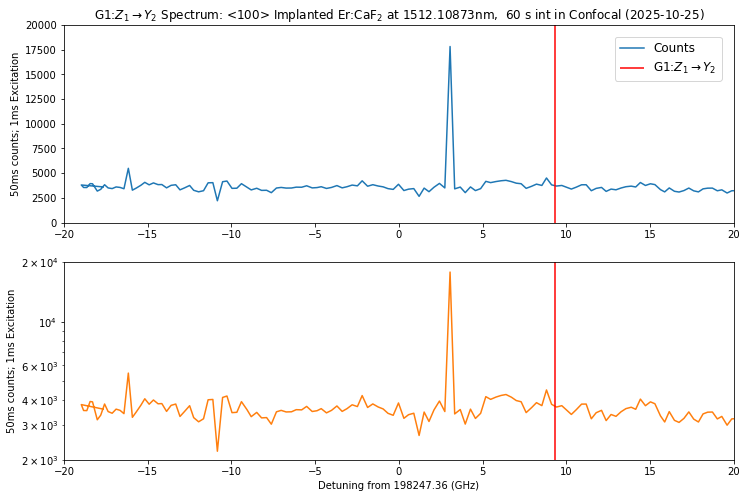

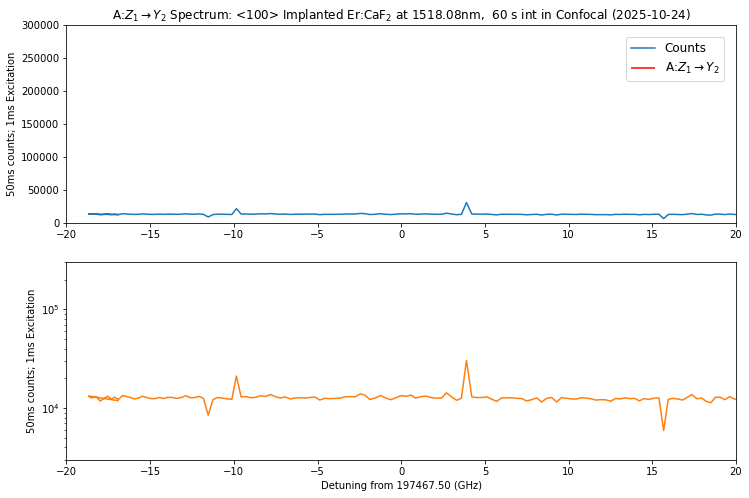

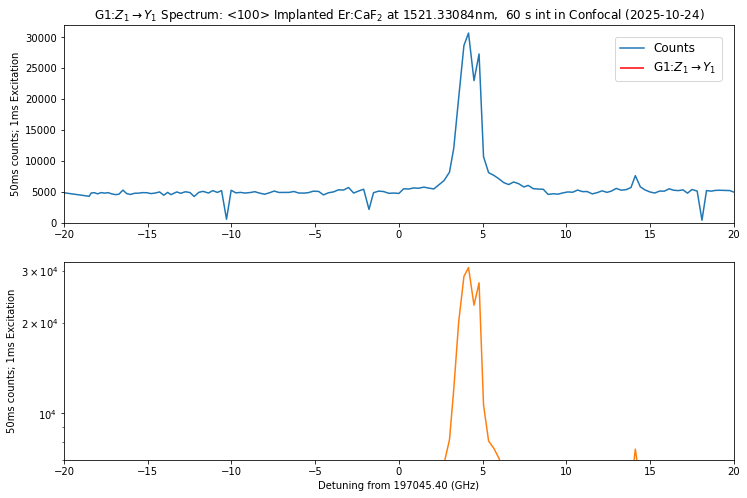

In [162]:
# PLotting routine  - count first 100 bins
for i, wave in enumerate(subFolderWavelengths_1025):
    peaks = []
    pVs = []
    freqs = []
    threshold = 1E7

    folder = sortedFolders_1025[i]
    files = os.listdir(folder)
    files = [file for file in files if ".csv" in file]

    ylims = [[4e3, 25e3],
            [3.8e3, 15e3],
            [3e3, 13e3],
            [2e3, 20e3],
            [3e3, 300e3],
            [7e3, 32e3],
            [3e3, 35e3]]

    for file in files:
        fileRead = np.loadtxt(os.path.join(folder, file), delimiter=",")
        times, data = fileRead[0], fileRead[1]
        pV = float(file.split("_")[-2])
        freq = float(file.split("_")[2])
        counts =  np.sum(data[1:100])
        if counts > ylims[i][1]:
            counts = 0
        peaks.append(counts)                                                          # add the peak to the list of peaks            
        pVs.append(pV)                                                              # add the voltage associated with this peak to the list of voltages
        freqs.append(freq)

    peaks = np.array(peaks)
    pVs = np.array(pVs)
    freqs = np.array(freqs)
    centre_freq = np.mean(freqs) # freqs returns MHz
    lines_detuned = (lines[i] - centre_freq)/1e3

    fig = plt.figure(figsize = (12, 8))
    norm_spectrum = fig.add_subplot(2, 1, 1)
    norm_spectrum.plot((freqs - centre_freq)/1e3, peaks, c = 'C0', label = 'Counts')
    norm_spectrum.set_ylabel(r'50ms counts; 1ms Excitation')
    norm_spectrum.vlines((lines_detuned), 0, ylims[i][1], colors = 'red', label = lines_label[i])
    norm_spectrum.set_ylim([0, ylims[i][1]])
    norm_spectrum.set_xlim([-20, 20])
    norm_spectrum.legend(fontsize = 12, borderaxespad = 1)

    log_spectrum = fig.add_subplot(2, 1, 2)
    log_spectrum.semilogy((freqs - centre_freq)/1e3, peaks, c = 'C1')
    log_spectrum.set_xlabel(fr'Detuning from {centre_freq/1e3:.2f} (GHz)')
    log_spectrum.set_ylabel(r'50ms counts; 1ms Excitation')
    log_spectrum.vlines((lines_detuned), 0, 2*ylims[i][1], colors = 'red', label = lines_label[i])
    log_spectrum.set_ylim([ylims[i][0], ylims[i][1]])
    log_spectrum.set_xlim([-20, 20])

    norm_spectrum.set_title(fr'{lines_label[i]} Spectrum: <100> Implanted Er:CaF$_2$ at {wave}nm,  {intTime} s int in Confocal ({folderDates[i]})')

    spectrum_array = np.array(freqs, counts)

    save_path_csv = os.path.join(os.path.dirname(sortedFolders_1018[i]), f'spectrum_{wave}nm.csv')
    save_path_png = os.path.join(os.path.dirname(sortedFolders_1018[i]), f'spectrum_{wave}nm.png')
    np.savetxt(save_path_csv, spectrum_array, delimiter = ',')
    plt.savefig(save_path_png, dpi=300, bbox_inches='tight')

    plt.show()

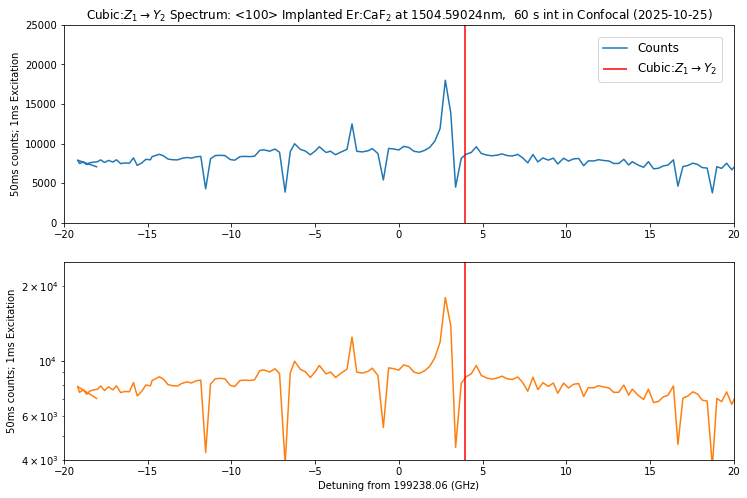

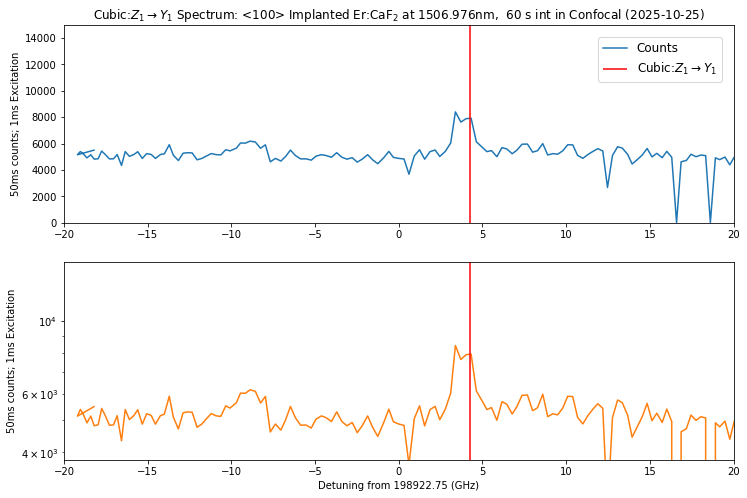

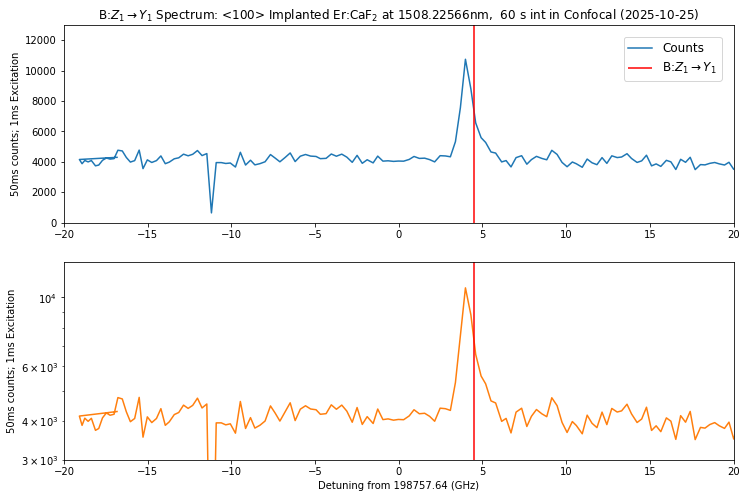

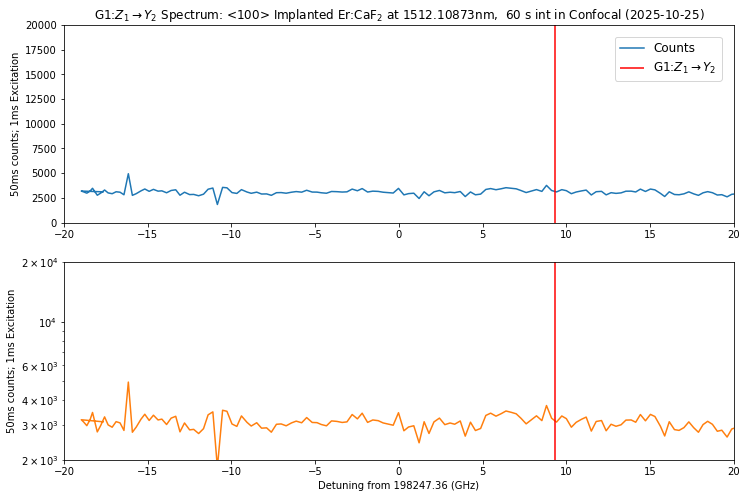

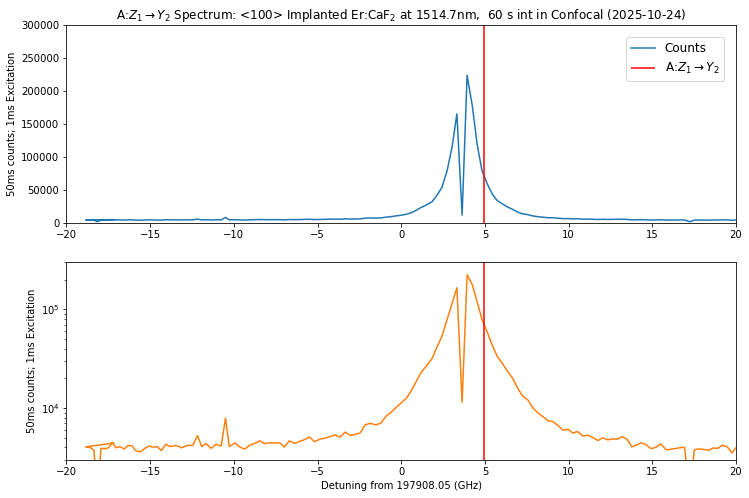

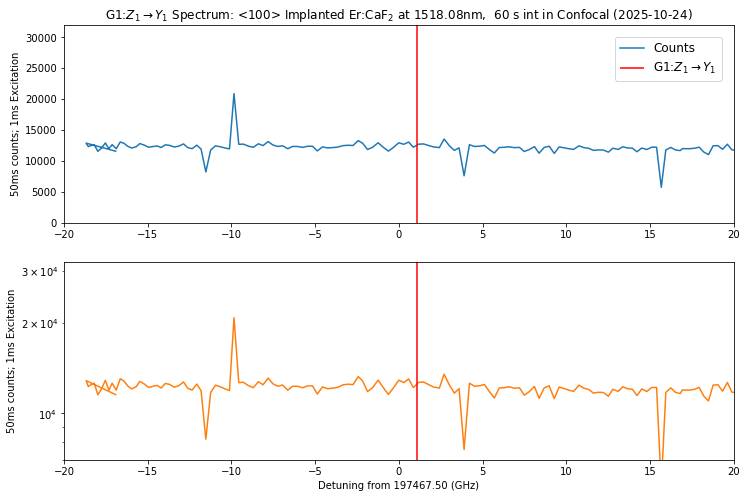

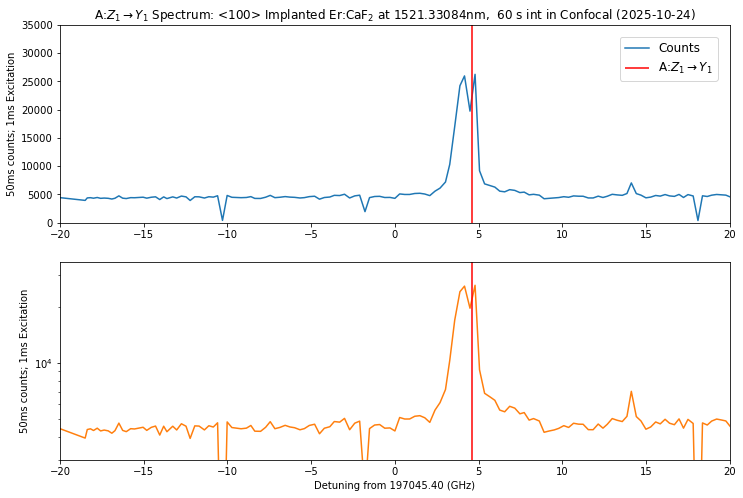

NotADirectoryError: [WinError 267] The directory name is invalid: 'data/2025-10-25/confocal\\run10\\spectrum_1504.59024nm.csv'

In [168]:
# PLotting routine  - count first 60 bins
for i, wave in enumerate(subFolderWavelengths_1025):
    peaks = []
    pVs = []
    freqs = []
    threshold = 1E7

    folder = sortedFolders_1025[i]
    files = os.listdir(folder)
    files = [file for file in files if ".csv" in file]

    ylims = [[4e3, 25e3],
            [3.8e3, 15e3],
            [3e3, 13e3],
            [2e3, 20e3],
            [3e3, 300e3],
            [7e3, 32e3],
            [3e3, 35e3]]

    for file in files:
        fileRead = np.loadtxt(os.path.join(folder, file), delimiter=",")
        times, data = fileRead[0], fileRead[1]
        pV = float(file.split("_")[-2])
        freq = float(file.split("_")[2])
        counts =  np.sum(data[1:60])
        if counts > ylims[i][1]:
            counts = 0
        peaks.append(counts)                                                          # add the peak to the list of peaks            
        pVs.append(pV)                                                              # add the voltage associated with this peak to the list of voltages
        freqs.append(freq)

    peaks = np.array(peaks)
    pVs = np.array(pVs)
    freqs = np.array(freqs)
    centre_freq = np.mean(freqs) # freqs returns MHz
    lines_detuned = (lines[i] - centre_freq)/1e3

    fig = plt.figure(figsize = (12, 8))
    norm_spectrum = fig.add_subplot(2, 1, 1)
    norm_spectrum.plot((freqs - centre_freq)/1e3, peaks, c = 'C0', label = 'Counts')
    norm_spectrum.set_ylabel(r'50ms counts; 1ms Excitation')
    norm_spectrum.vlines((lines_detuned), 0, ylims[i][1], colors = 'red', label = lines_label[i])
    norm_spectrum.set_ylim([0, ylims[i][1]])
    norm_spectrum.set_xlim([-20, 20])
    norm_spectrum.legend(fontsize = 12, borderaxespad = 1)

    log_spectrum = fig.add_subplot(2, 1, 2)
    log_spectrum.semilogy((freqs - centre_freq)/1e3, peaks, c = 'C1')
    log_spectrum.set_xlabel(fr'Detuning from {centre_freq/1e3:.2f} (GHz)')
    log_spectrum.set_ylabel(r'50ms counts; 1ms Excitation')
    log_spectrum.vlines((lines_detuned), 0, 2*ylims[i][1], colors = 'red', label = lines_label[i])
    log_spectrum.set_ylim([ylims[i][0], ylims[i][1]])
    log_spectrum.set_xlim([-20, 20])

    norm_spectrum.set_title(fr'{lines_label[i]} Spectrum: <100> Implanted Er:CaF$_2$ at {wave}nm,  {intTime} s int in Confocal ({folderDates[i]})')

    spectrum_array = np.array(freqs, counts)

    save_path_csv = os.path.join(os.path.dirname(sortedFolders_1025[i]), f'spectrum_{wave}nm.csv')
    save_path_png = os.path.join(os.path.dirname(sortedFolders_1025[i]), f'spectrum_{wave}nm.png')
    np.savetxt(save_path_csv, spectrum_array, delimiter = ',')
    plt.savefig(save_path_png, dpi=300, bbox_inches='tight')

    plt.show()

# Looking for Erbium

In [ ]:
from scipy import stats
import re

cols = ['#f94144', '#f3722c', '#f8961e', '#f9c74f', '#90be6d', '#43aa8b', '#577590']
savePath = 'data/2025-10-29/confocal/background fluorescence'

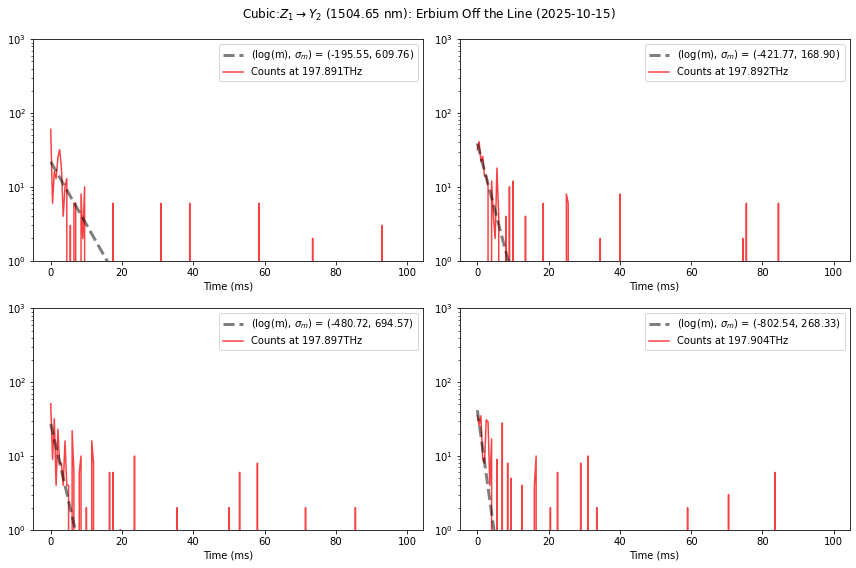

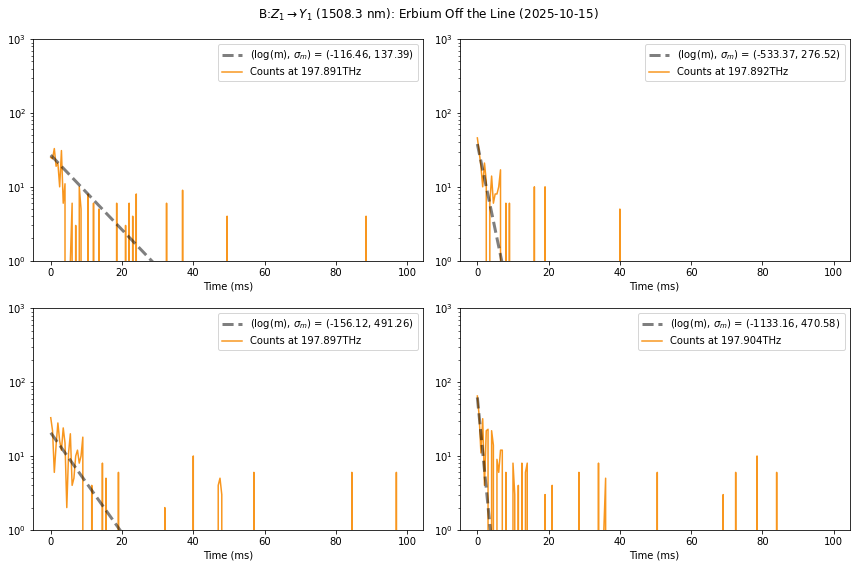

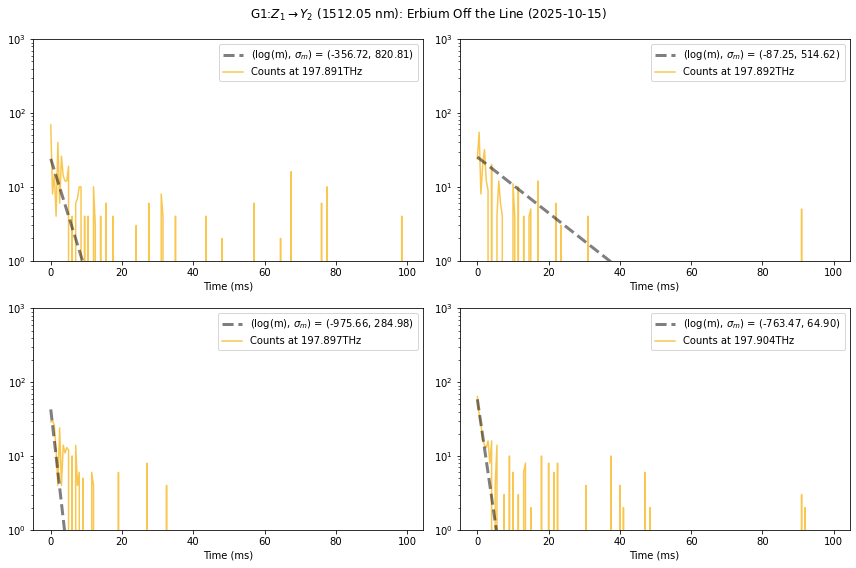

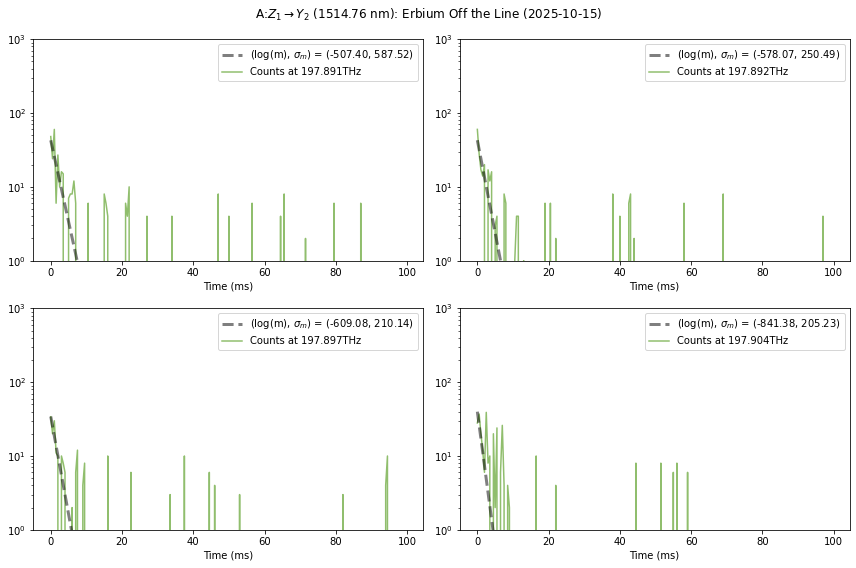

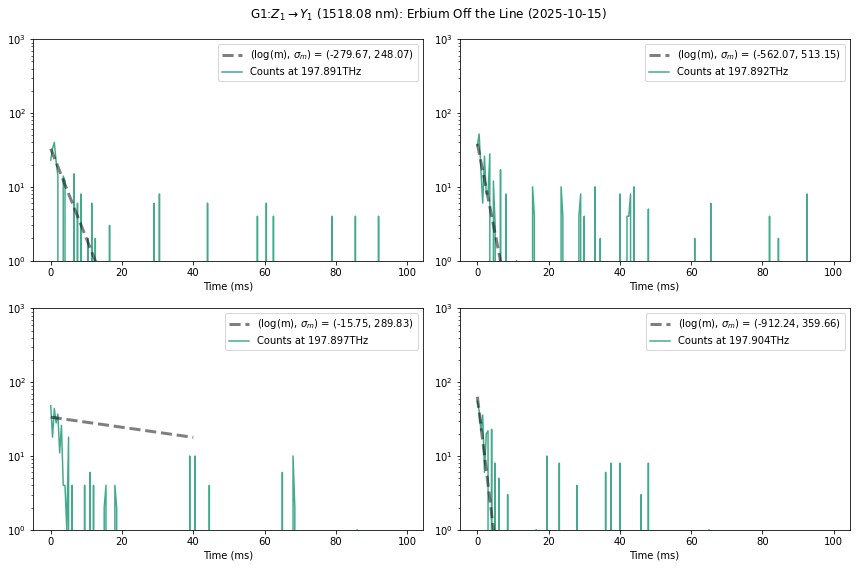

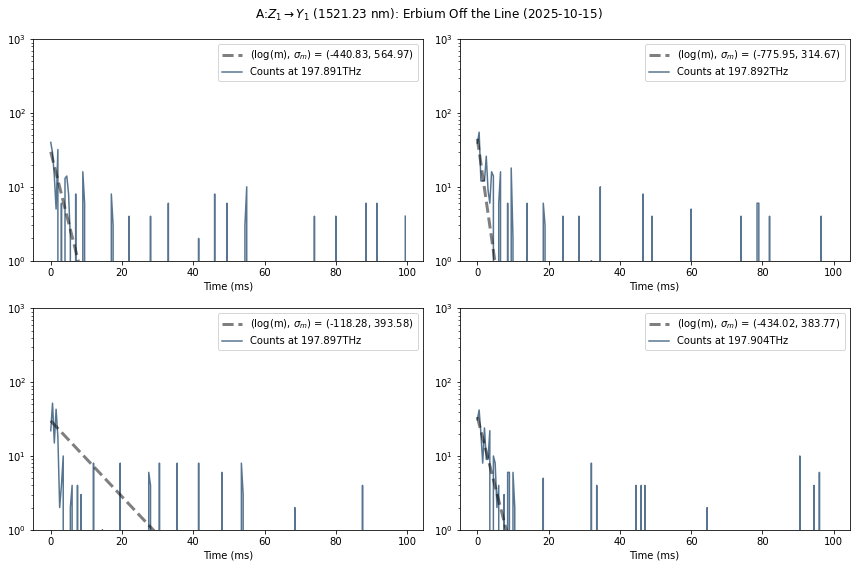

In [203]:
for i, wave in enumerate(subFolderWavelengths_1015):

    # Add theoretical location of lines
    lines = [199.242e6, # Cubic Z1-Y2
            198.76215e6, # B Z1-Y1
            198.2567e6, # G1 Z1-Y2
            197.913e6, # A Z1-Y2
            197.4686e6, # G1 Z1-Y1
            197.05e6] # A Z1-Y1  

    lines_label = [r'Cubic:$Z_1 \rightarrow Y_2$',
                r'B:$Z_1 \rightarrow Y_1$',
                r'G1:$Z_1 \rightarrow Y_2$',
                r'A:$Z_1 \rightarrow Y_2$',
                r'G1:$Z_1 \rightarrow Y_1$',
                r'A:$Z_1 \rightarrow Y_1$']
    
    cols = ['#f94144', '#f8961e', '#f9c74f', '#90be6d', '#43aa8b', '#577590']

    
    folder = sortedFolders_1015[i]
    folder_1015 = os.listdir(folder)
    fig = plt.figure(figsize = (12, 8))

    # choose to look at background time traces off the line and off the surface - before alignment
    choose = [5, 20, 100, 190] 

    for j, idx in enumerate(choose):
        tt = folder_1015[idx]
        ttPath = os.path.join(folder, tt)

        match = re.search(r'_freq_([0-9.]+)_MHz', tt)
        if match:
            freq = float(match.group(1))

        data = np.loadtxt(ttPath, delimiter = ',')
        subp = fig.add_subplot(2, 2, j+1)
        subp.semilogy(data[0, :]*1e3, data[1, :], c = cols[i], label = f'Counts at {freq*1e-6:.3f}THz')
        subp.set_xlabel('Time (ms)')

        # Linear regression on first 10 ms
        slope, intercept, r, p, std_err = stats.linregress(data[0, 0:5], np.log(data[1, 0:5]))
        tFit = np.linspace(0, 40e-3, 2)
        countFit = np.exp(slope * tFit + intercept)
        subp.plot(tFit*1e3, countFit, 
                  c = 'k', linestyle = '--', alpha = 0.5, linewidth = 3, 
                  label = rf'(log(m), $\sigma_m$) = ({slope:.2f}, {std_err:.2f})')
        subp.set_ylim([1, 1e3])
        handles, labels = subp.get_legend_handles_labels()
        subp.legend(handles[::-1], labels[::-1], loc='upper right')

    fig.suptitle(f'{lines_label[i]} ({wave} nm): Erbium Off the Line ({folderDates_1015[i]})')
    plt.tight_layout()
    plt.savefig(os.path.join(savePath, f'{wave} background.png'))

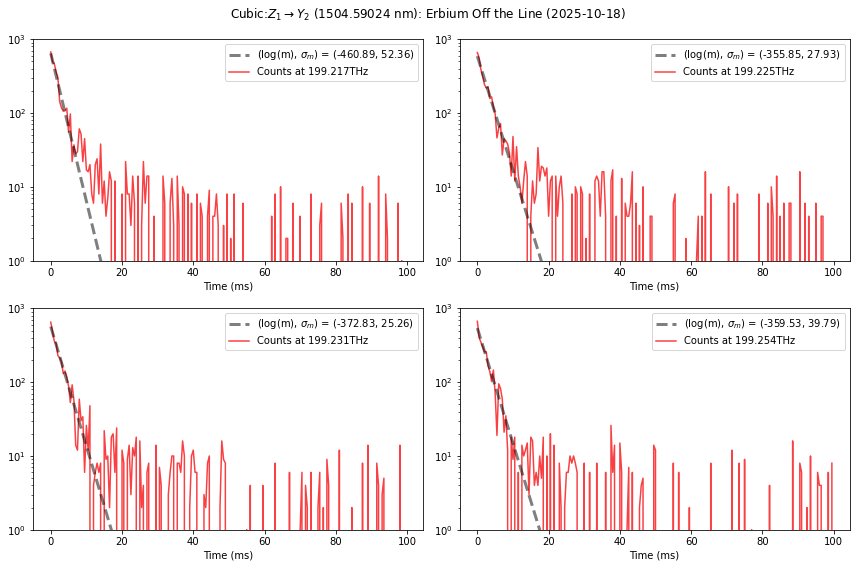

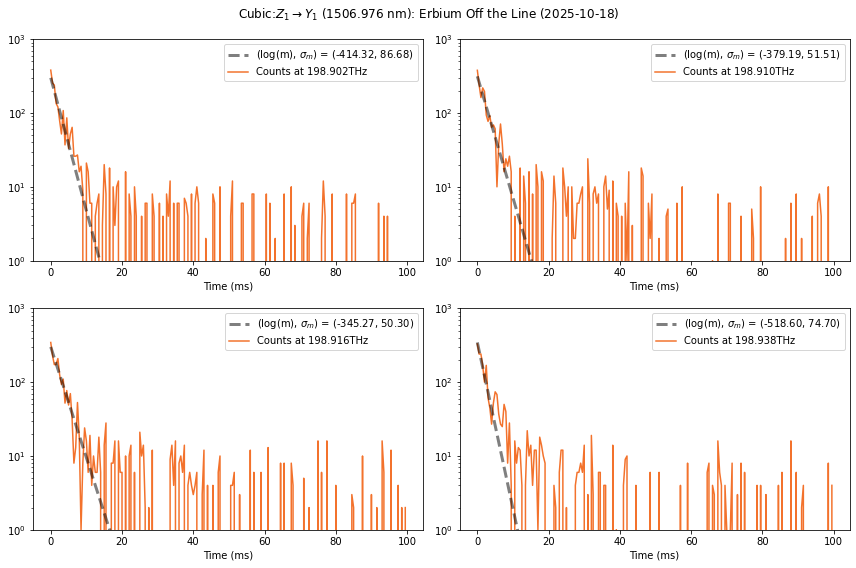

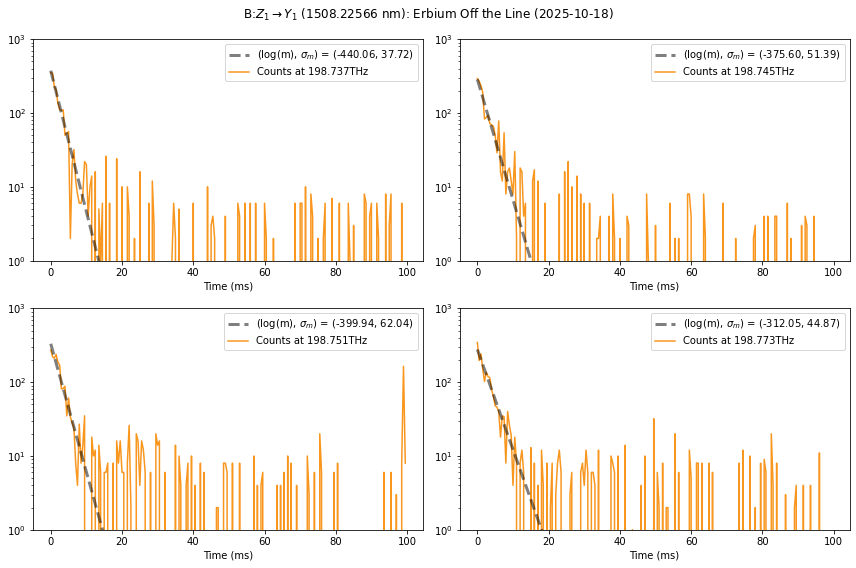

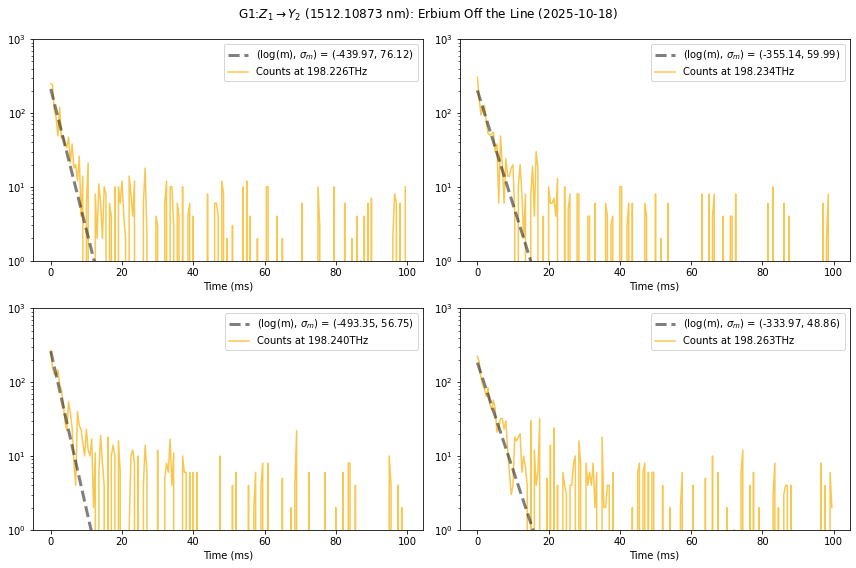

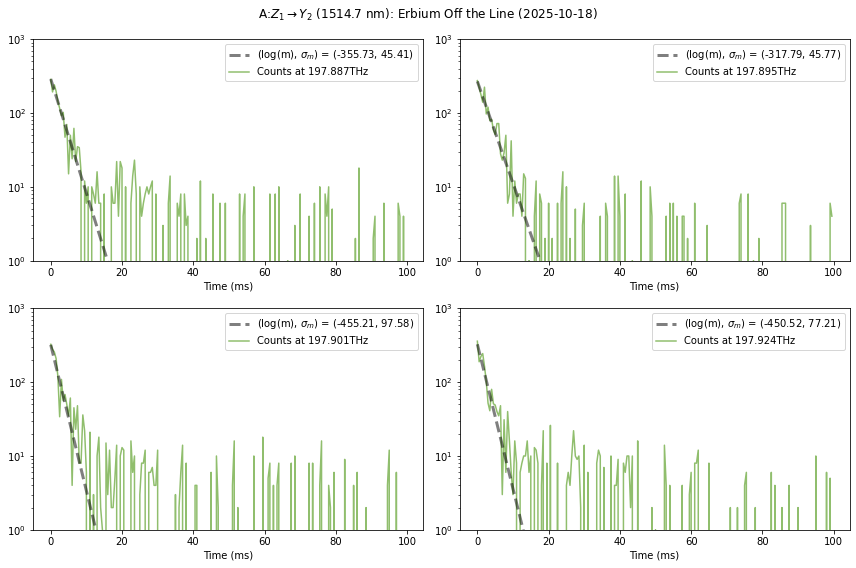

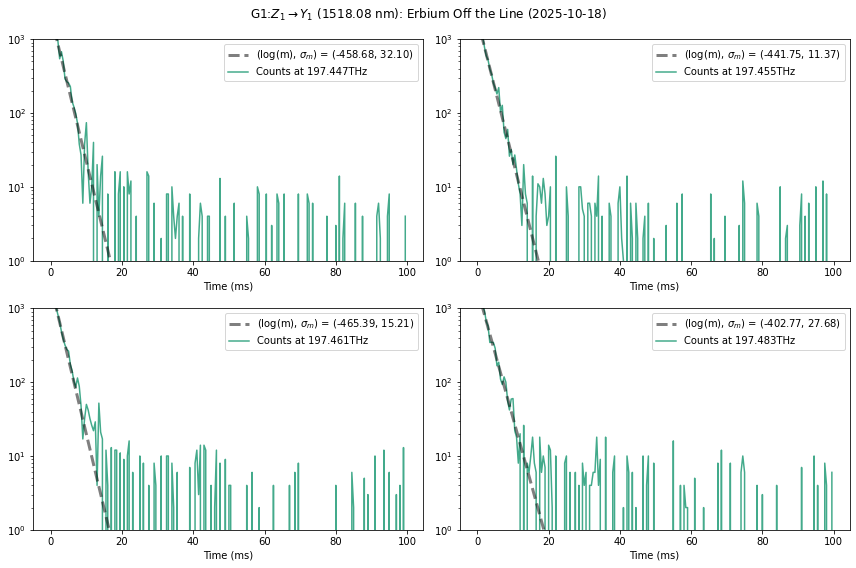

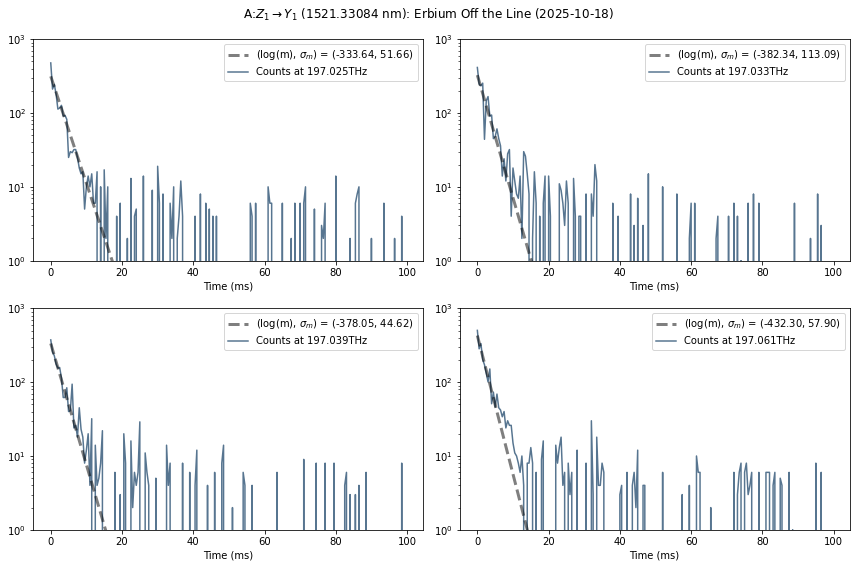

In [144]:
for i, wave in enumerate(subFolderWavelengths_1018):
    folder = sortedFolders_1018[i]
    folder_1018 = os.listdir(folder)
    fig = plt.figure(figsize = (12, 8))

    # choose to look at background time traces off the line
    choose = [10, 40, 60, 135] 

    for j, idx in enumerate(choose):
        tt = folder_1018[idx]
        ttPath = os.path.join(folder, tt)

        match = re.search(r'_freq_([0-9.]+)_MHz', tt)
        if match:
            freq = float(match.group(1))

        data = np.loadtxt(ttPath, delimiter = ',')
        subp = fig.add_subplot(2, 2, j+1)
        subp.semilogy(data[0, :]*1e3, data[1, :], c = cols[i], label = f'Counts at {freq*1e-6:.3f}THz')
        subp.set_xlabel('Time (ms)')

        # Linear regression on first 10 ms
        slope, intercept, r, p, std_err = stats.linregress(data[0, 0:10], np.log(data[1, 0:10]))
        tFit = np.linspace(0, 40e-3, 2)
        countFit = np.exp(slope * tFit + intercept)
        subp.plot(tFit*1e3, countFit, 
                  c = 'k', linestyle = '--', alpha = 0.5, linewidth = 3, 
                  label = rf'(log(m), $\sigma_m$) = ({slope:.2f}, {std_err:.2f})')
        subp.set_ylim([1, 1e3])
        handles, labels = subp.get_legend_handles_labels()
        subp.legend(handles[::-1], labels[::-1], loc='upper right')

    fig.suptitle(f'{lines_label[i]} ({wave} nm): Erbium Off the Line ({folderDates_1018[i]})')
    plt.tight_layout()
    plt.savefig(os.path.join(savePath, f'{wave} background.png'))

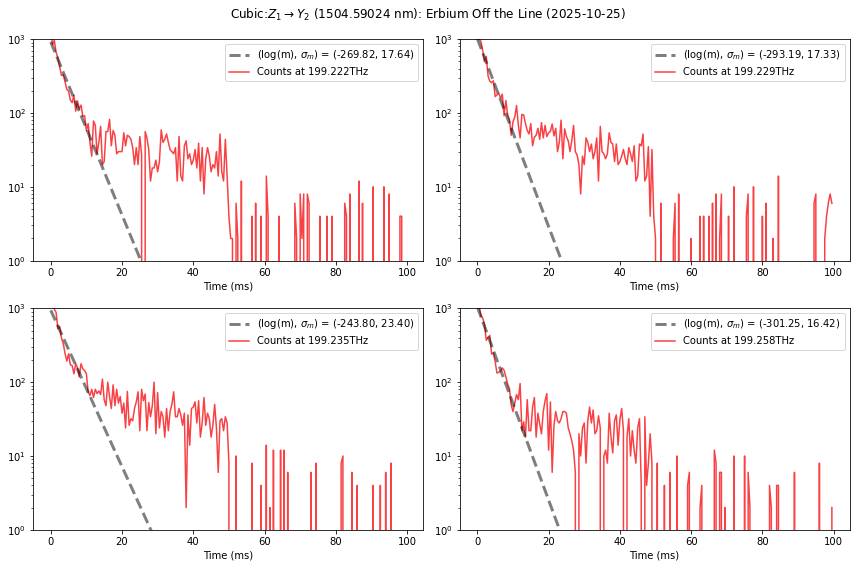

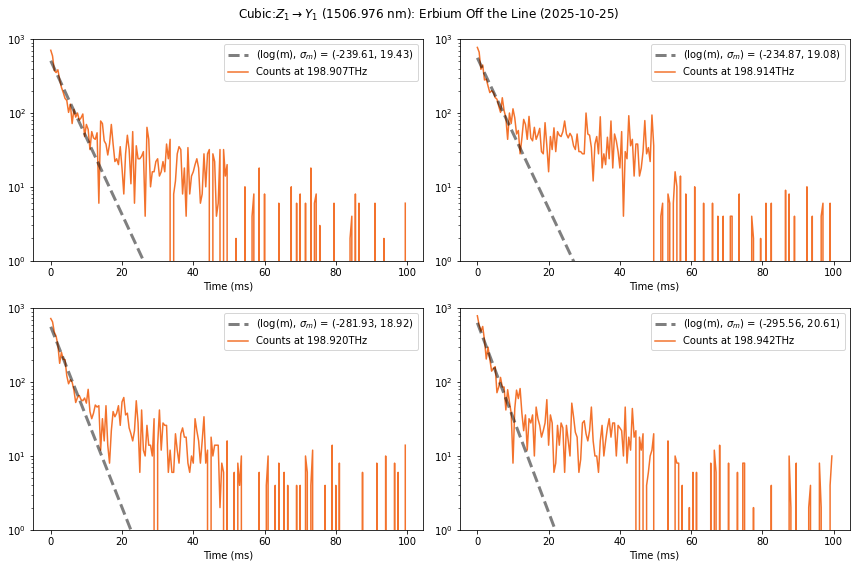

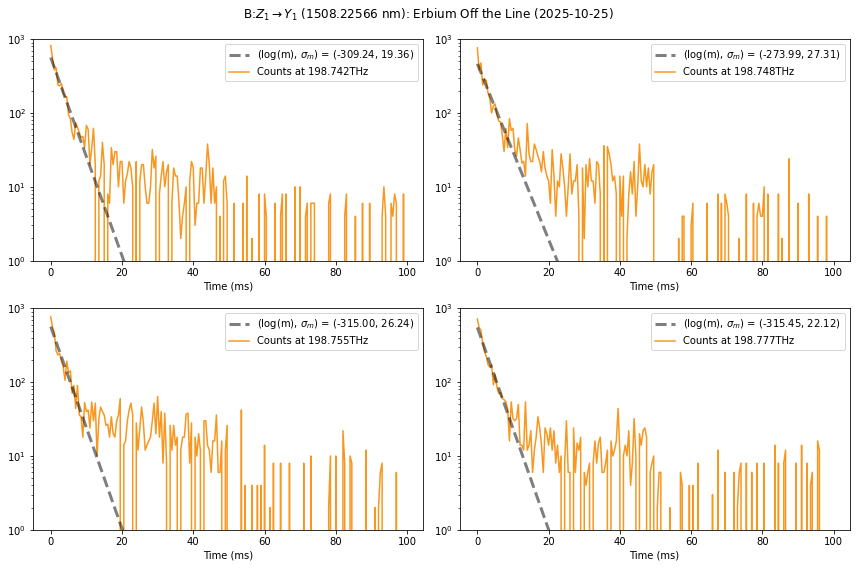

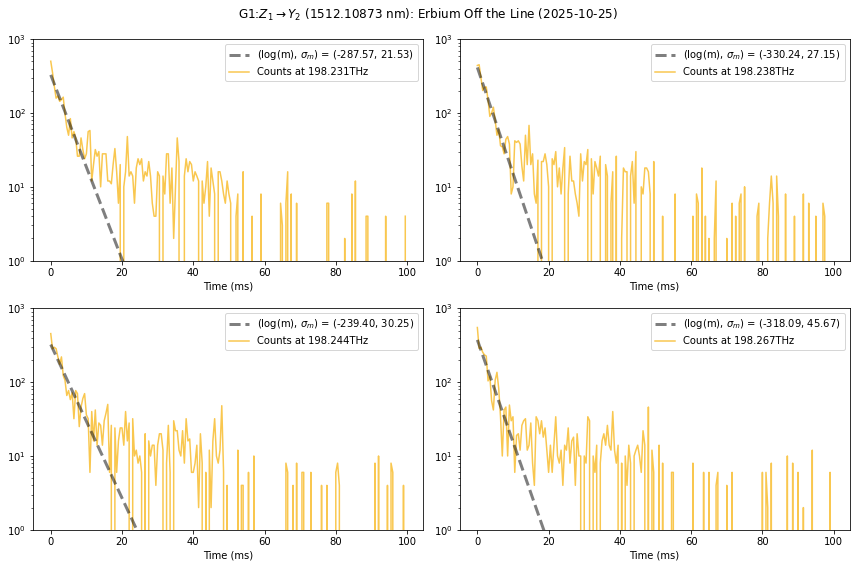

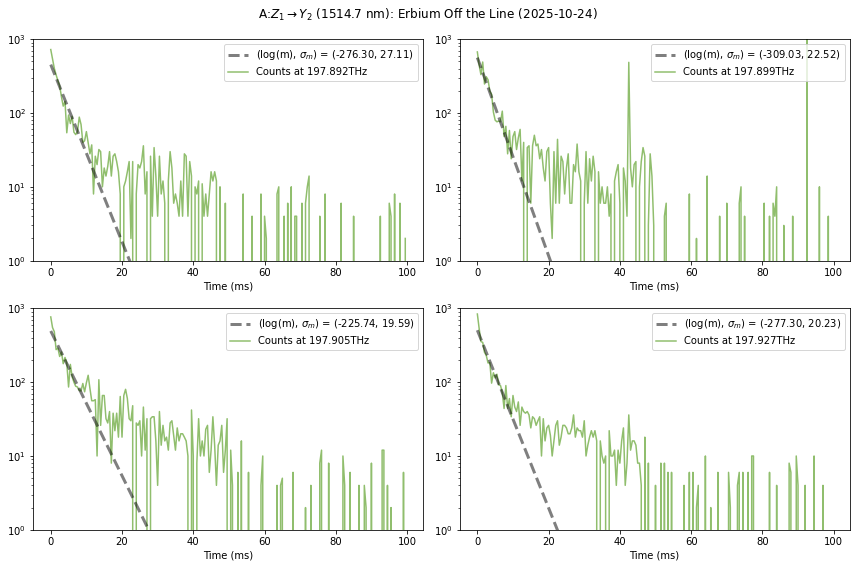

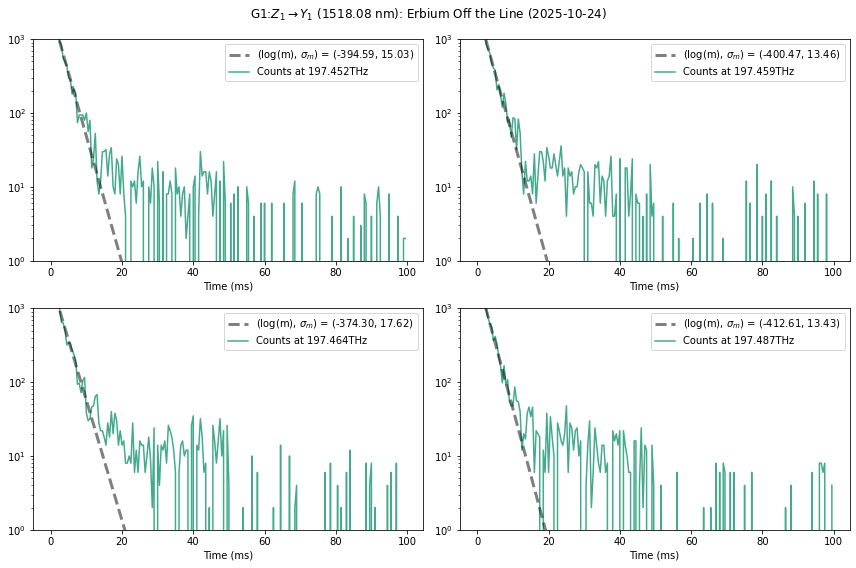

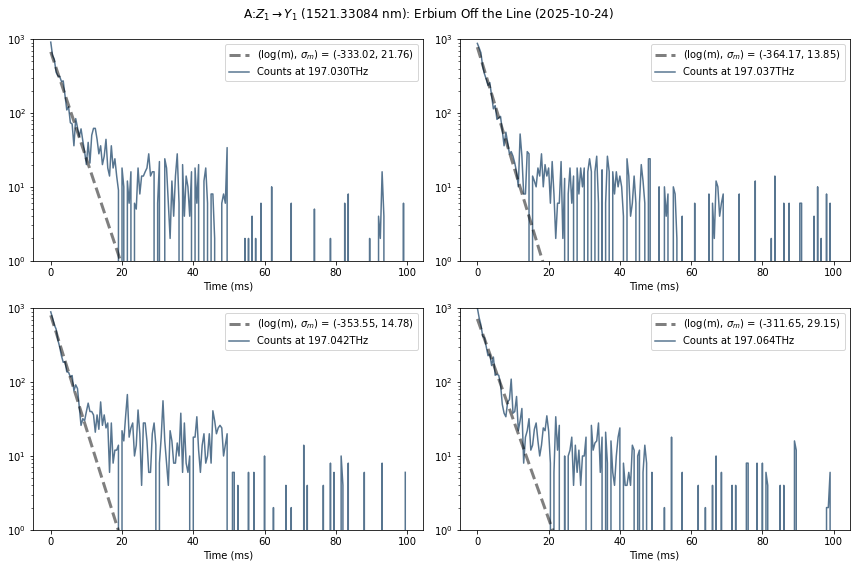

In [154]:
for i, wave in enumerate(subFolderWavelengths_1025):
    folder = sortedFolders_1025[i]
    folder_1025 = os.listdir(folder)
    fig = plt.figure(figsize = (12, 8))

    # choose to look at background time traces off the line
    choose = [15, 40, 60, 135] 

    for j, idx in enumerate(choose):
        tt = folder_1025[idx]
        ttPath = os.path.join(folder, tt)

        match = re.search(r'_freq_([0-9.]+)_MHz', tt)
        if match:
            freq = float(match.group(1))

        data = np.loadtxt(ttPath, delimiter = ',')
        subp = fig.add_subplot(2, 2, j+1)
        subp.semilogy(data[0, :]*1e3, data[1, :], c = cols[i], label = f'Counts at {freq*1e-6:.3f}THz')
        subp.set_xlabel('Time (ms)')

        # Linear regression on first 10 ms
        slope, intercept, r, p, std_err = stats.linregress(data[0, 0:20], np.log(data[1, 0:20]))
        tFit = np.linspace(0, 40e-3, 2)
        countFit = np.exp(slope * tFit + intercept)
        subp.plot(tFit*1e3, countFit, 
                  c = 'k', linestyle = '--', alpha = 0.5, linewidth = 3, 
                  label = rf'(log(m), $\sigma_m$) = ({slope:.2f}, {std_err:.2f})')
        subp.set_ylim([1, 1e3])
        handles, labels = subp.get_legend_handles_labels()
        subp.legend(handles[::-1], labels[::-1], loc='upper right')

    fig.suptitle(f'{lines_label[i]} ({wave} nm): Erbium Off the Line ({folderDates_1025[i]})')
    plt.tight_layout()
    plt.savefig(os.path.join(savePath, f'{wave} background.png'))

# Revisiting 10/18 and 10/25
### The inefficient way

In [127]:
# Spectrum Parameters
scanHalf = 70       # [V]
n = 140
lineCentre = 70
intTime= 60
excTime = 1
bias = -0.9

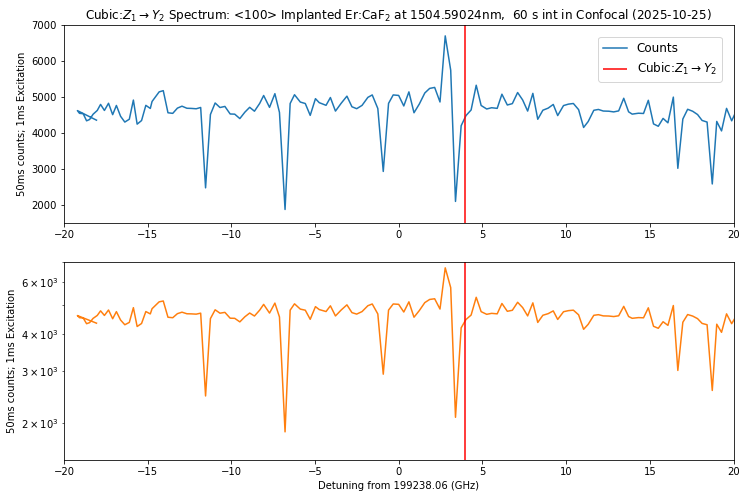

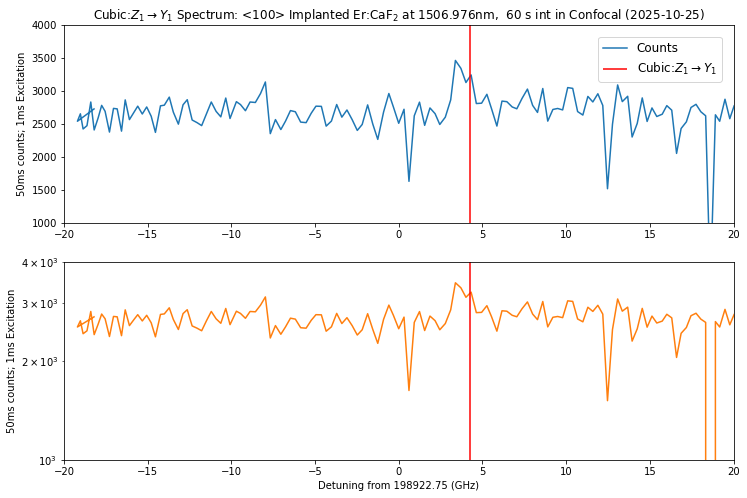

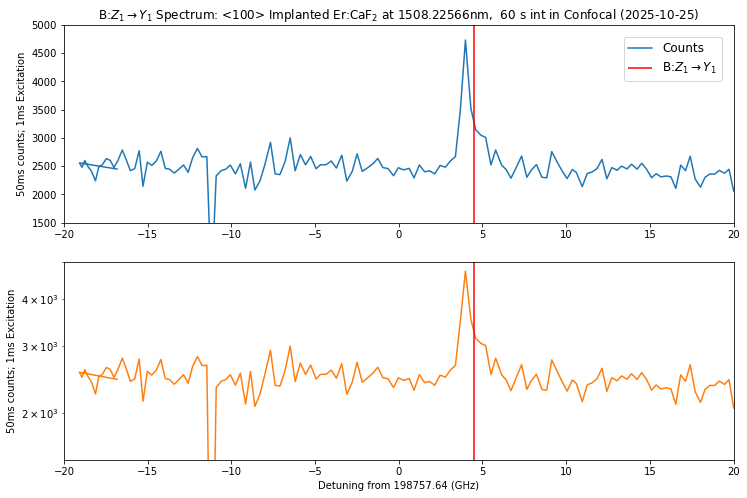

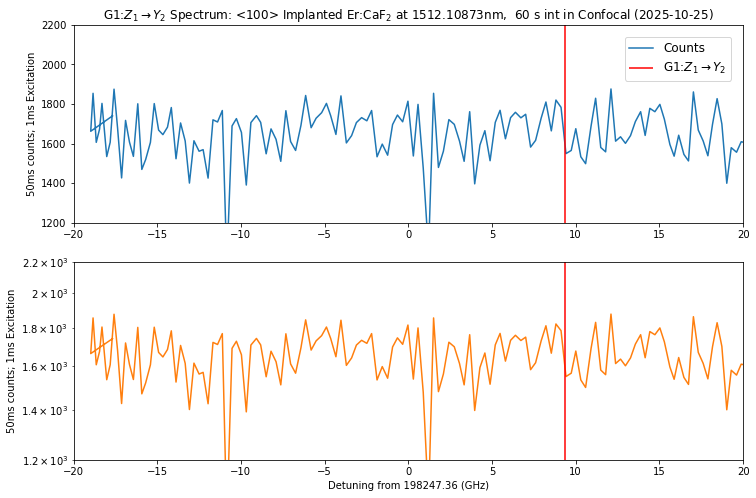

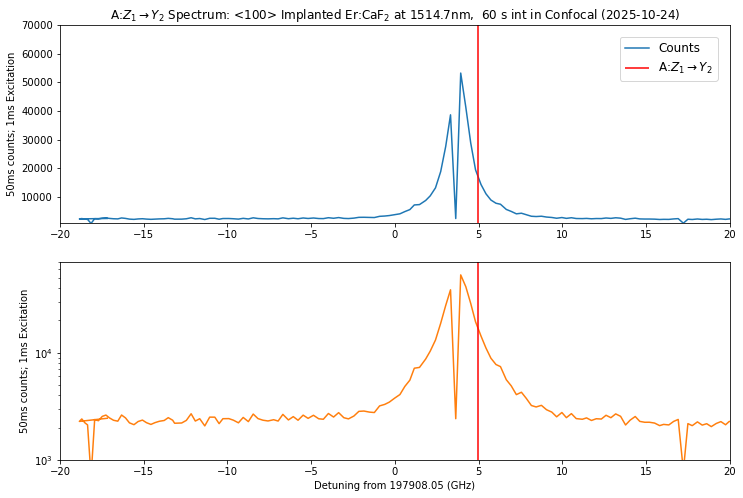

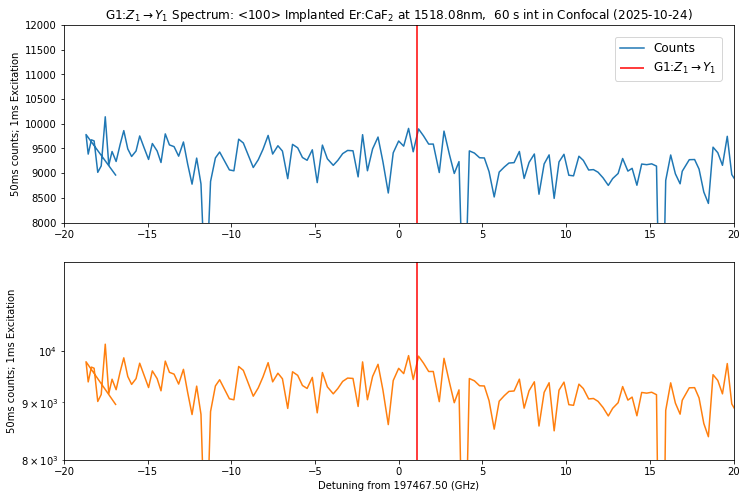

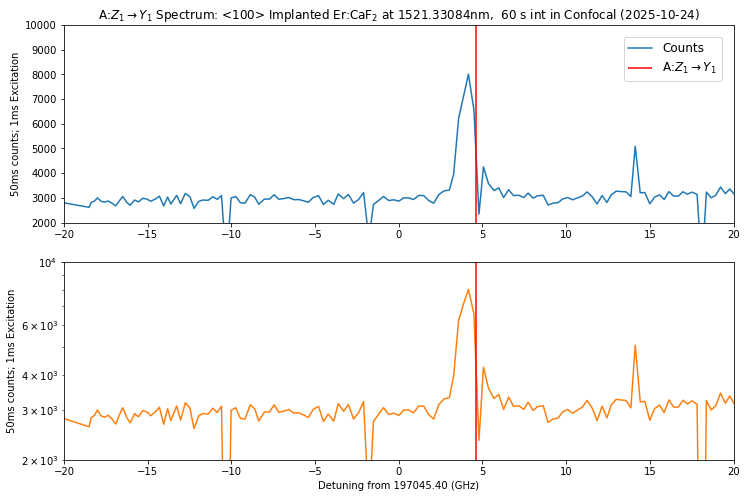

In [ ]:
# PLotting routine, summed over first 9 bins (4 ms)
lines = [199.242e6, # Cubic Z1-Y2
        198.927e6, # Cubic Z1-Y1  
        198.76215e6, # B Z1-Y1
        198.2567e6, # G1 Z1-Y2
        197.913e6, # A Z1-Y2
        197.4686e6, # G1 Z1-Y1
        197.05e6] # A Z1-Y1  

lines_label = [r'Cubic:$Z_1 \rightarrow Y_2$',
               r'Cubic:$Z_1 \rightarrow Y_1$',
               r'B:$Z_1 \rightarrow Y_1$',
               r'G1:$Z_1 \rightarrow Y_2$',
               r'A:$Z_1 \rightarrow Y_2$',
               r'G1:$Z_1 \rightarrow Y_1$',
               r'A:$Z_1 \rightarrow Y_1$']
                
for i, wave in enumerate(subFolderWavelengths_1025):
    peaks = []
    pVs = []
    freqs = []

    folder = sortedFolders_1025[i]
    files = os.listdir(folder)
    files = [file for file in files if ".csv" in file]

    ylims = [[1.5e3, 7e3],
            [1e3, 4e3],
            [1.5e3, 5e3],
            [1.2e3, 2.2e3],
            [1e3, 7e4],
            [8e3, 12e3],
            [2e3, 1e4]]

    for file in files:
        fileRead = np.loadtxt(os.path.join(folder, file), delimiter=",")
        times, data = fileRead[0], fileRead[1]
        pV = float(file.split("_")[-2])
        freq = float(file.split("_")[2])
        counts =  np.sum(data[1:9])
        if counts > ylims[i][1]:
            counts = 0
        peaks.append(counts)                                                          # add the peak to the list of peaks            
        pVs.append(pV)                                                              # add the voltage associated with this peak to the list of voltages
        freqs.append(freq)

    peaks = np.array(peaks)
    pVs = np.array(pVs)
    freqs = np.array(freqs)
    centre_freq = np.mean(freqs) # freqs returns MHz
    lines_detuned = (lines[i] - centre_freq)/1e3

    fig = plt.figure(figsize = (12, 8))
    norm_spectrum = fig.add_subplot(2, 1, 1)
    norm_spectrum.plot((freqs - centre_freq)/1e3, peaks, c = 'C0', label = 'Counts')
    norm_spectrum.set_ylabel(r'50ms counts; 1ms Excitation')
    norm_spectrum.vlines((lines_detuned), 0, ylims[i][1], colors = 'red', label = lines_label[i])
    norm_spectrum.set_ylim([ylims[i][0], ylims[i][1]])
    norm_spectrum.set_xlim([-20, 20])
    norm_spectrum.legend(fontsize = 12, borderaxespad = 1)

    log_spectrum = fig.add_subplot(2, 1, 2)
    log_spectrum.semilogy((freqs - centre_freq)/1e3, peaks, c = 'C1')
    log_spectrum.set_xlabel(fr'Detuning from {centre_freq/1e3:.2f} (GHz)')
    log_spectrum.set_ylabel(r'50ms counts; 1ms Excitation')
    log_spectrum.vlines((lines_detuned), 0, 2*ylims[i][1], colors = 'red', label = lines_label[i])
    log_spectrum.set_ylim([ylims[i][0], ylims[i][1]])
    log_spectrum.set_xlim([-20, 20])

    norm_spectrum.set_title(fr'{lines_label[i]} Spectrum: <100> Implanted Er:CaF$_2$ at {wave}nm,  {intTime} s int in Confocal ({folderDates_1025[i]})')
    save_path_png = os.path.join(f'spectrum_{wave}nm.png')
    save_path_csv = os.path.join(f'spectrum_{wave}nm.csv')

    spectrum_array = np.array(freqs, counts)

    save_path_csv = os.path.join(os.path.dirname(sortedFolders_1018[i]), f'spectrum_{wave}nm_9bins.csv')
    save_path_png = os.path.join(os.path.dirname(sortedFolders_1018[i]), f'spectrum_{wave}nm_9bins.png')
    np.savetxt(save_path_csv, spectrum_array, delimiter = ',')
    plt.savefig(save_path_png, dpi=300, bbox_inches='tight')

    plt.show()

## Now, implementing as a function

In [ ]:
## Setting up function for plotting spectrum - previous plotting code transposed by chatgpt
def plot_spectra(
    folderPath,
    numBins,
    intTime,
    excTime,
    lines,
    linesLabel,
    ylims,
    cols, 
    save,
    savePath
):
    """
    Plot normalized and logarithmic spectra for multiple datasets.

    Parameters
    ----------
    lines : list of float
        Reference transition frequencies (Hz).
    linesLabel : list of str
        Labels corresponding to each reference frequency.
    numBins : int
        Number of bins to sum over for each file.
    intTime : float
        Integration time in seconds (used for plot title).
    ylims : list of [float, float]
        Y-axis limits (min, max) for each dataset.
    save : controls whether plots are saved to folderPath origin,
    savePath: str
        Path to save the plots and data if save is True.
    """
    sortedFolders = sorted(folderPath,
                        key = lambda x: os.path.basename(x))
    subFolderWavelengths = [os.path.basename(os.path.normpath(p)) for p in sortedFolders]
    folderDates = [os.path.normpath(p).split(os.sep)[1] for p in sortedFolders]
    
    for i, wave in enumerate(subFolderWavelengths):
        peaks = []
        freqs = []
        pVs = []

        folder = sortedFolders[i]
        files = [f for f in os.listdir(folder) if f.endswith(".csv")]

        for file in files:
            file_path = os.path.join(folder, file)
            fileRead = np.loadtxt(file_path, delimiter=",")
            times, data = fileRead[0], fileRead[1]

            pV = float(file.split("_")[-2])
            freq = float(file.split("_")[2])
            counts = np.sum(data[1:numBins + 1])
            timeLimit = times[numBins]

            # Ignore saturated counts
            if counts > ylims[i][1]:
                counts = 0

            peaks.append(counts)
            freqs.append(freq)
            pVs.append(pV)

        freqs = np.array(freqs)
        peaks = np.array(peaks)
        freqsVpeaks = pd.DataFrame(np.vstack((freqs, peaks))).T # n x 2 array with column 0 = frequencies and column 1 = counts
        freqsVpeaks = freqsVpeaks.rename(columns = {0: r'Frequencies (GHz)', 1: fr'Counts over {timeLimit*1e3} (ms)'})
        freqsVpeaks = freqsVpeaks.sort_values(by = r'Frequencies (GHz)')
        
        centreFreq = np.mean(freqs)
        linesDetuned = (lines[i] - centreFreq) / 1e3  # detuning in GHz

        # ---- Plot ----
        fig = plt.figure(figsize=(12, 8))

        # Linear plot
        norm_ax = fig.add_subplot(2, 1, 1)
        norm_ax.scatter((freqsVpeaks[r'Frequencies (GHz)'] - centreFreq) / 1e3, freqsVpeaks[fr'Counts over {timeLimit*1e3} (ms)'], 
                        c = cols[6], s = 5) 
        norm_ax.plot((freqsVpeaks[r'Frequencies (GHz)'] - centreFreq) / 1e3, freqsVpeaks[fr'Counts over {timeLimit*1e3} (ms)'], 
                    c = cols[6], alpha = 0.6, 
                    label=f'Counts over {timeLimit*1e3} ms')
        norm_ax.vlines(linesDetuned, 0, ylims[i][1], 
                    colors = cols[0], label=linesLabel[i])
        norm_ax.set_ylabel(fr'{timeLimit*1e3}ms counts; {excTime}ms Excitation')
        norm_ax.set_ylim(ylims[i])
        norm_ax.set_xlim([-20, 20])
        norm_ax.legend(fontsize=12, borderaxespad=1)

        # Log plot
        log_ax = fig.add_subplot(2, 1, 2)
        log_ax.semilogy((freqsVpeaks[r'Frequencies (GHz)'] - centreFreq) / 1e3, freqsVpeaks[fr'Counts over {timeLimit*1e3} (ms)'], 
                        marker = 'o', linestyle = 'none', markersize = 2, color = cols[2]) 
        log_ax.semilogy((freqsVpeaks[r'Frequencies (GHz)'] - centreFreq) / 1e3, freqsVpeaks[fr'Counts over {timeLimit*1e3} (ms)'], 
                        color = cols[2], alpha = 0.7)
        log_ax.vlines(linesDetuned, 0, 2 * ylims[i][1], 
                    colors = cols[0], label=linesLabel[i])
        log_ax.set_xlabel(fr'Detuning from {centreFreq / 1e3:.2f} (GHz)')
        log_ax.set_ylabel(fr'{timeLimit*1e3}ms counts; {excTime}ms Excitation')
        log_ax.set_ylim(ylims[i])
        log_ax.set_xlim([-20, 20])

        title = fr'{linesLabel[i]} Spectrum: <100> Implanted Er:CaF$_2$ at {wave} nm, {intTime}s int in Confocal ({folderDates[i]})'
        norm_ax.set_title(title)

        if save == True:
            save_path_csv = os.path.join(savePath, f'spectrum_{wave}nm_{numBins}bins.csv')
            save_path_png = os.path.join(savePath, f'spectrum_{wave}nm_{numBins}bins.png')

            spectrum_array = np.column_stack((freqs, peaks))
            np.savetxt(save_path_csv, spectrum_array, delimiter=',', header='freq_Hz,counts', comments='')
            plt.savefig(save_path_png, dpi=300, bbox_inches='tight')
        
        plt.show()
        
    return freqsVpeaks

In [ ]:
# plotting process transposed into function using chatgpt
def plot_time_traces(
    folderPath,
    numBins,
    choose,
    cols,
    save,
    savePath,
    plot
):
    """
    Plot background time traces of chosen index and perform
    exponential decay fits on the specified numBins.

    Parameters
    ----------
    folderPath : str
        Path to the folder containing .csv time-trace files.
    numBins : number of overs to perform linear regression on.
    choose : list of 4 integers within index range
        List of file indices to plot from the folder (e.g., [5, 20, 100, 190]).
    save : boolean
        Choose whether to save fitted time traces    
    savePath : str, optional
        Directory to save the resulting figure. If None, saves in `folderPath`.
    """
    
    # cols = ["#f3722c", '#f8961e', '#f09c00', "#43aa8b", '#099295', '#006275', "#2557C2"]
    sortedFolders = sorted(folderPath,
                        key = lambda x: os.path.basename(x))
    subFolderWavelengths = [os.path.basename(os.path.normpath(p)) for p in sortedFolders]
    folderDates = [os.path.normpath(p).split(os.sep)[1] for p in sortedFolders]
    wavelengths = np.zeros([len(choose), len(subFolderWavelengths)])
    lifetimes = np.zeros([len(choose), len(subFolderWavelengths)])
    lifetimeErrors = np.zeros([len(choose), len(subFolderWavelengths)])
    
    for i, wave in enumerate(subFolderWavelengths):
        folder = sortedFolders[i]
        files = sorted(os.listdir(folder))
        if plot == True:
            fig = plt.figure(figsize = (10, 5))

        for j, idx in enumerate(choose):
            timeTrace = files[int(idx)]
            timeTracePath = os.path.join(folder, timeTrace)
            fileRead = np.loadtxt(timeTracePath, delimiter=",")
            time, data = fileRead[0], fileRead[1]

            # Extract frequency from filename
            match = re.search(r'_freq_([0-9.]+)_MHz', timeTracePath)
            freq = float(match.group(1)) if match else np.nan

            # Load time-trace data
            data = np.loadtxt(timeTracePath, delimiter=',')
            time = data[0, :]  # seconds
            counts = data[1, :]

            if plot == True:
                # Plot raw data
                subp = fig.add_subplot(2, 2, j + 1)
                subp.semilogy(time * 1e3, counts,
                            marker = 'o', linestyle = 'none', markersize = 2, color = cols[i])
                subp.semilogy(time * 1e3, counts,
                            color = cols[i], alpha = 0.6,
                            label=f'Counts at {freq * 1e-6:.3f} THz' if not np.isnan(freq) else 'Counts')
                subp.set_xlim([0, 100])
                subp.set_xlabel('Time (ms)')
                subp.set_ylabel('Counts')

            # --- Linear regression (log fit) on numBins ---
            slope, intercept, _, _, std_err = stats.linregress(time[0:numBins], np.log(counts[0:numBins]))
            lifetime = -1/slope*1e3 # in ms
            lifetime_error = lifetime * std_err/slope
            lifetimes[j, i] = lifetime
            lifetimeErrors[j, i] = lifetime_error
            wavelengths[j, i] = wave

            t_fit = np.linspace(0, np.max(time), 200)
            count_fit = np.exp(slope * t_fit + intercept)

            if plot == True:
                subp.plot(
                    t_fit * 1e3, count_fit,
                    c='k', linestyle='--', alpha=0.7, linewidth=2,
                    label=rf'[T, $\sigma_T$ ] = [{lifetime:.2f}, {lifetime_error:.2f}]'
                    )
                subp.set_ylim([1, 1e3])
                handles, labels = subp.get_legend_handles_labels()
                subp.legend(handles[::-1], labels[::-1], loc='upper right')

                # Figure title and layout
                fig.suptitle(f'{lines_label[i]} ({wave} nm): Erbium Off the Line ({folderDates[i]})')
                plt.tight_layout()

        if save == True:
            os.makedirs(savePath, exist_ok = True)
            save_file = os.path.join(savePath, f'{wave}_background.png')
            plt.savefig(save_file, dpi=300, bbox_inches='tight')
        
        if plot == True:
            plt.show()       
            
    return wavelengths, lifetimes, lifetimeErrors

In [199]:
from scipy import stats

### 2025-10-18: Function approach

In [167]:
folders_1018 = (glob.glob('data/2025-10-18/*'))
print(folders_1018)

['data/2025-10-18/1518.08', 'data/2025-10-18/1514.7', 'data/2025-10-18/1504.59024', 'data/2025-10-18/1521.33084', 'data/2025-10-18/1512.10873', 'data/2025-10-18/1506.976', 'data/2025-10-18/1508.22566']


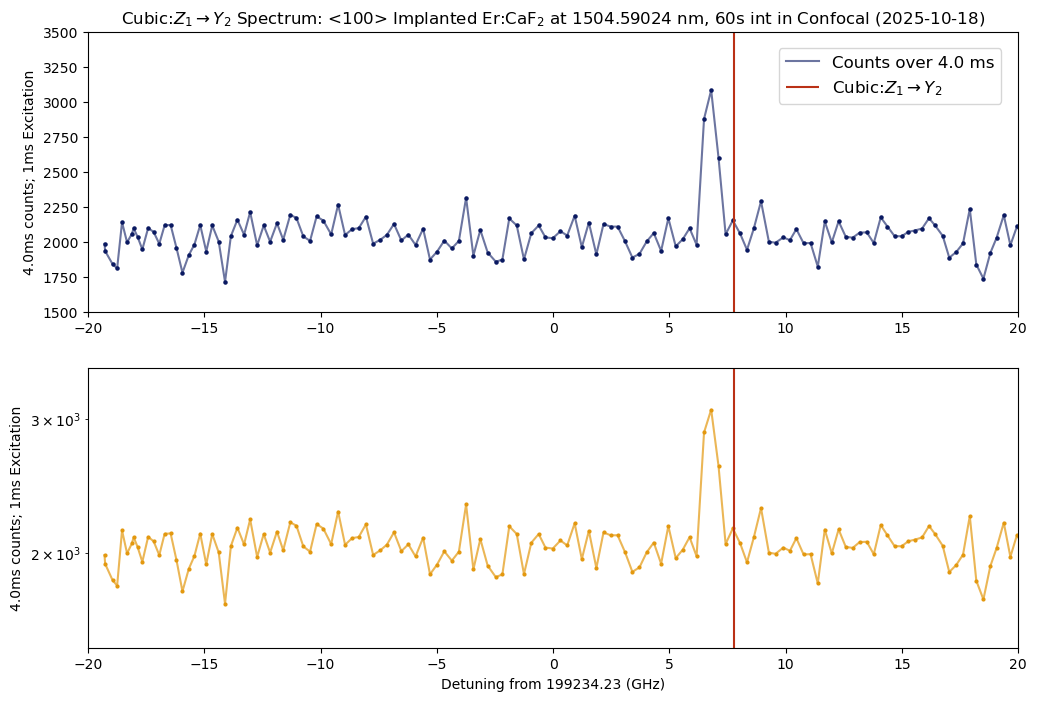

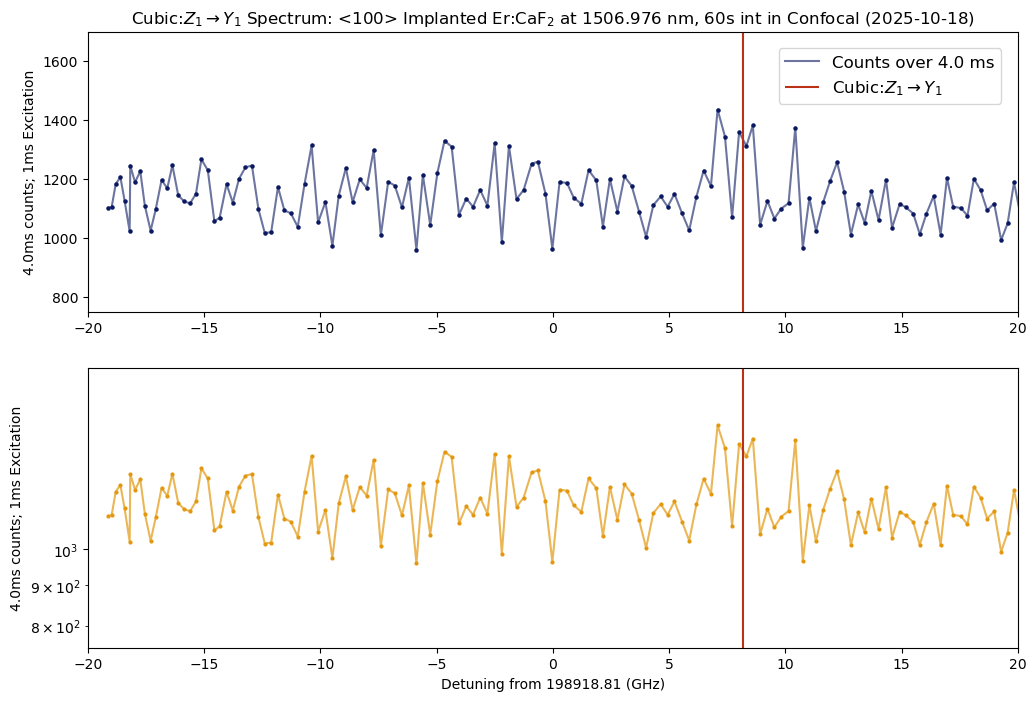

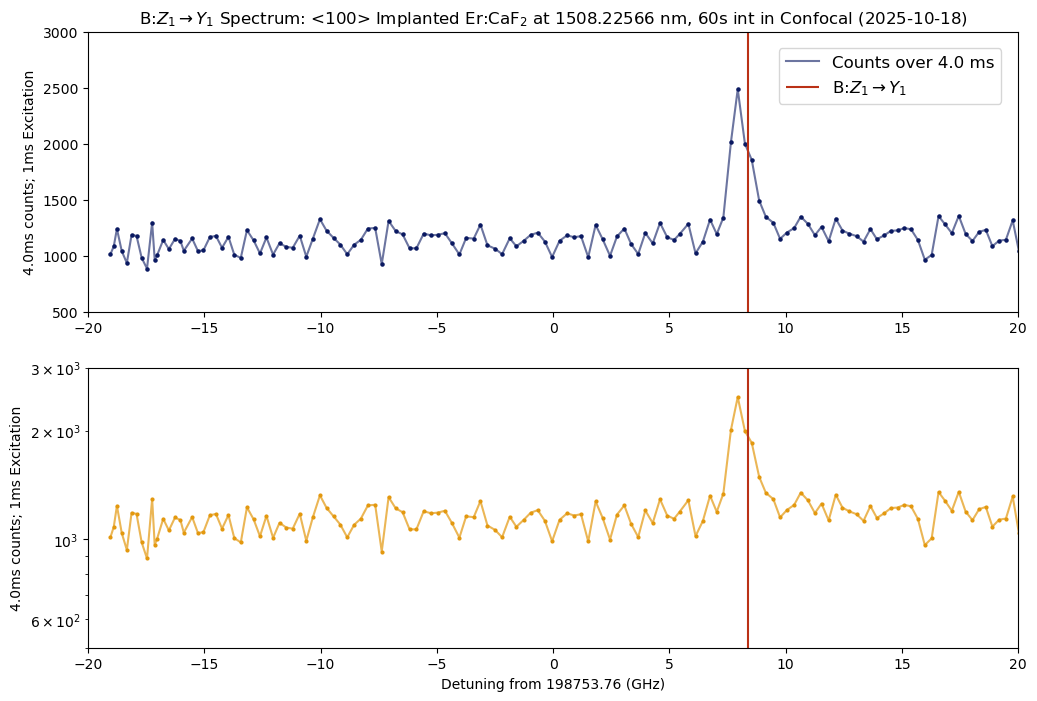

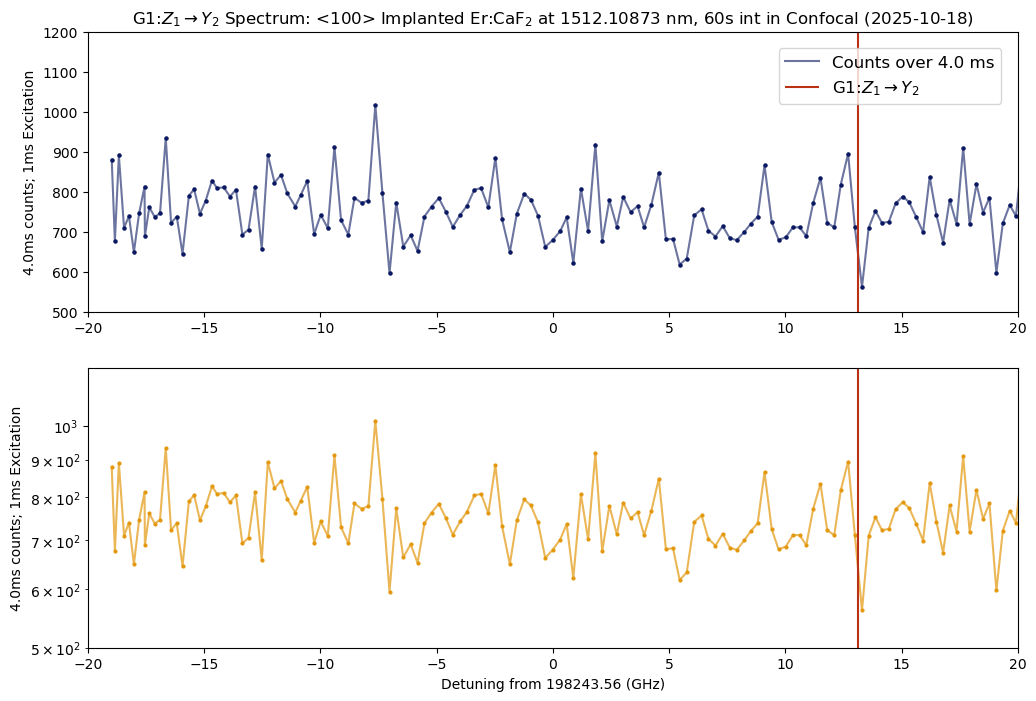

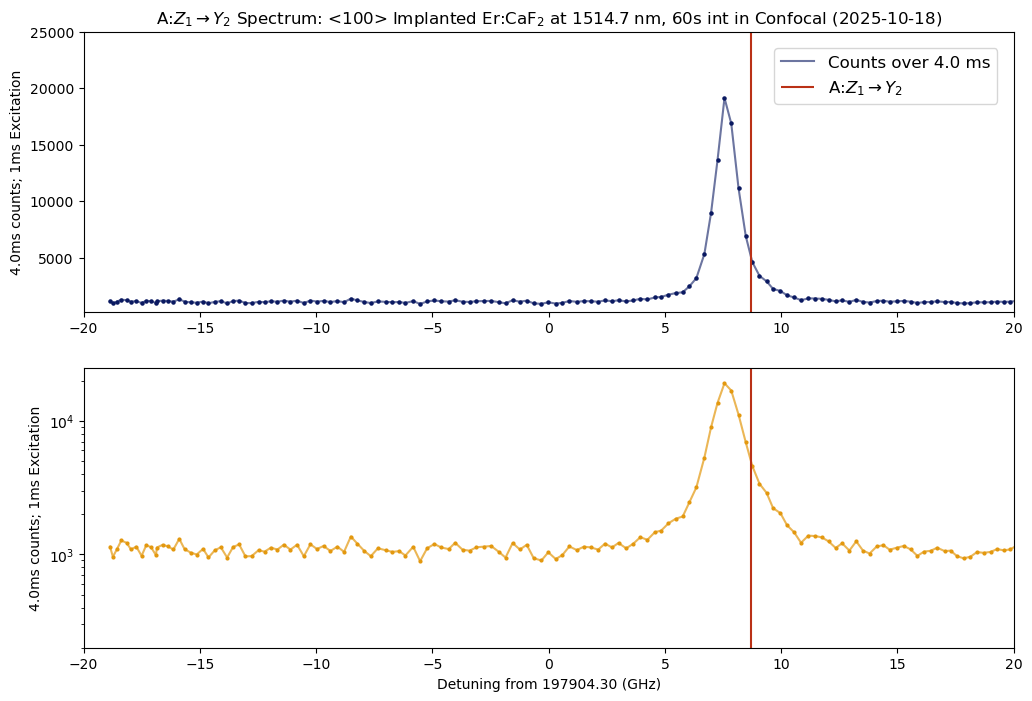

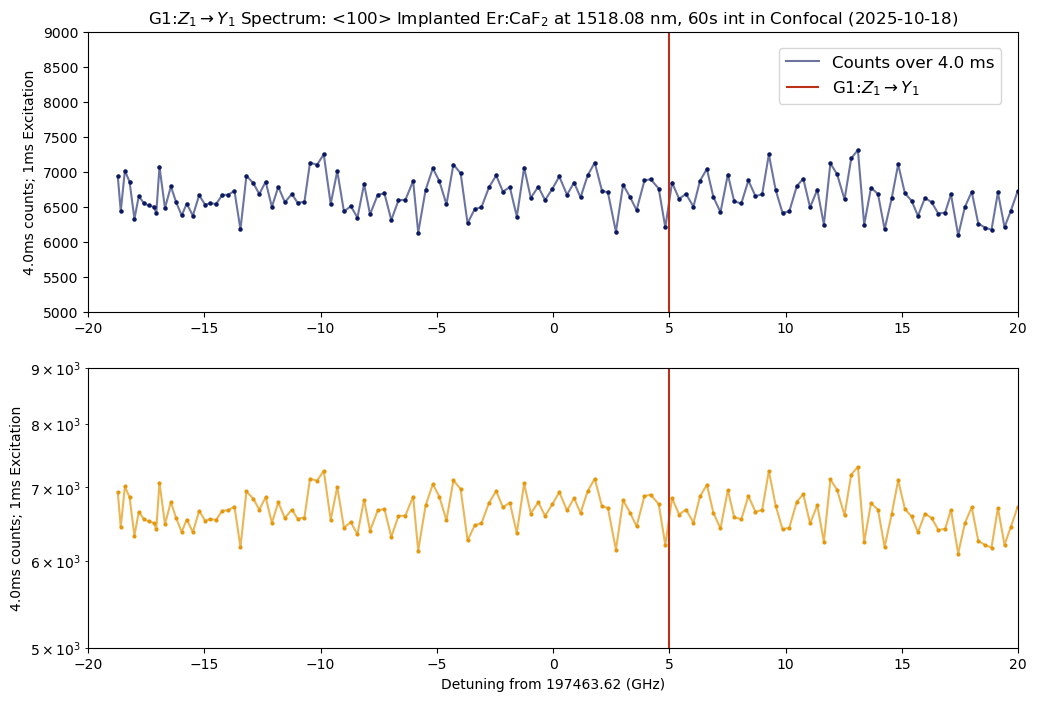

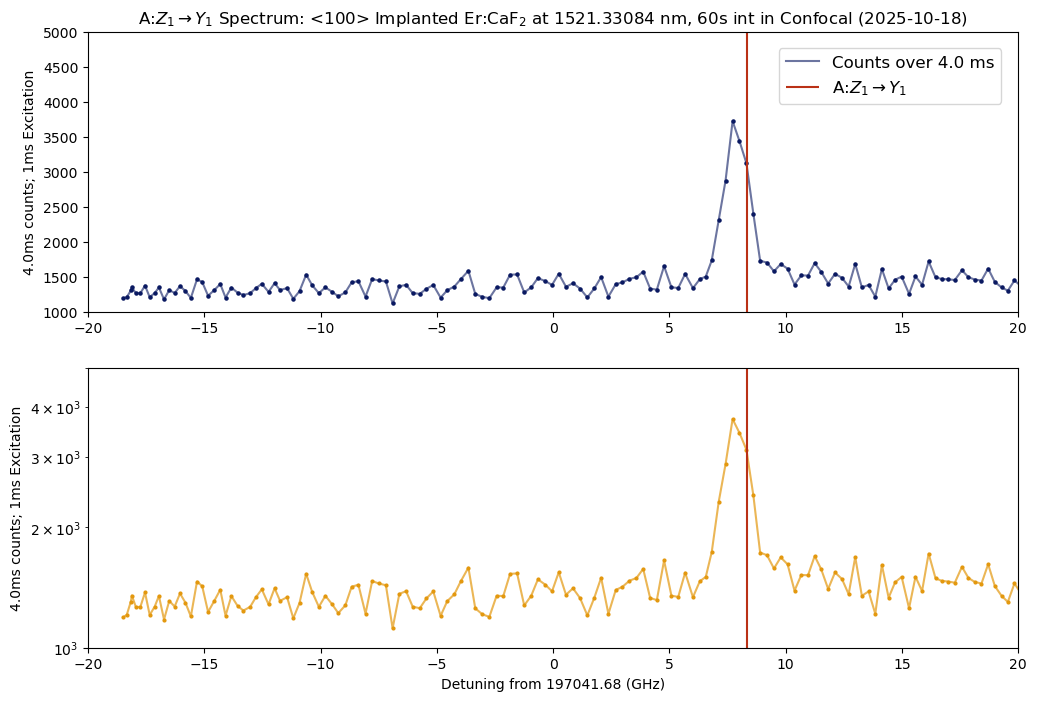

In [272]:
lines = [199.242e6, # Cubic Z1-Y2
        198.927e6, # Cubic Z1-Y1  
        198.76215e6, # B Z1-Y1
        198.2567e6, # G1 Z1-Y2
        197.913e6, # A Z1-Y2
        197.4686e6, # G1 Z1-Y1
        197.05e6] # A Z1-Y1  

linesLabel = [r'Cubic:$Z_1 \rightarrow Y_2$',
               r'Cubic:$Z_1 \rightarrow Y_1$',
               r'B:$Z_1 \rightarrow Y_1$',
               r'G1:$Z_1 \rightarrow Y_2$',
               r'A:$Z_1 \rightarrow Y_2$',
               r'G1:$Z_1 \rightarrow Y_1$',
               r'A:$Z_1 \rightarrow Y_1$']

ylims_1018 = [[1.5e3, 3.5e3],
            [7.5e2, 1.7e3],
            [5e2, 3e3],
            [5e2, 1.2e3],
            [2e2, 2.5e4],
            [5e3, 9e3],
            [1e3, 5e3]]

cols = ["#BA3116", '#CE5F2C', "#E3980E", '#006275', "#03516E", '#2B448C', "#0A1961"]

fVp_1018 = plot_spectra(
    folderPath = folders_1018,
    numBins = 8,
    intTime = intTime,
    excTime = 1,
    lines = lines,
    linesLabel = linesLabel,
    ylims = ylims_1018,
    cols = cols,
    save = False,
    savePath = folders_1018) # need to define savepath

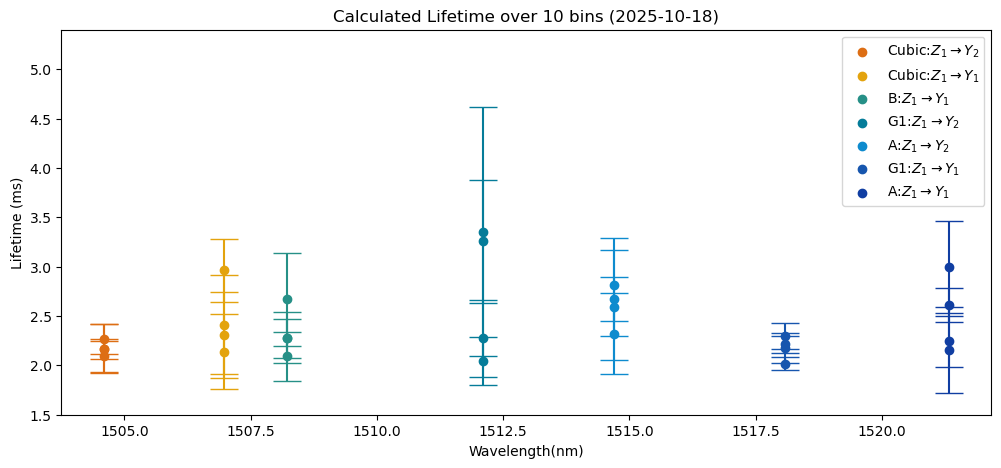

In [ ]:
choose = [4, 10, 130, 139] 
cols = ["#DD6E14", "#E3A30E", "#269087", "#057C99", "#0E8BCE", "#1756AE", "#103EA2"]
numBins = 10

wavelengths_1018, lifetimes_1018, lifetimeErrors_1018 = plot_time_traces(folderPath = folders_1018,
                    numBins = numBins,
                    choose = choose,
                    save = False,
                    cols = cols,
                    savePath = folders_1018,
                    plot = False)

plt.figure(figsize = (12, 5))
for i, col in enumerate(cols):
    plt.scatter(wavelengths_1018[:, i], lifetimes_1018[:, i], 
                color = cols[i],
                label = fr'{linesLabel[i]}')
    plt.errorbar(wavelengths_1018[:, i], lifetimes_1018[:, i], yerr = np.abs(lifetimeErrors_1018[:, i]), xerr = None, 
                fmt = 'none', capsize = 10, c = cols[i])

plt.xlabel('Wavelength(nm)')
plt.ylabel('Lifetime (ms)')
plt.ylim([1.5, 5.4])
plt.legend(loc = 'upper right')
plt.title(f'Calculated Lifetime over {numBins} bins (2025-10-18)')
plt.show()

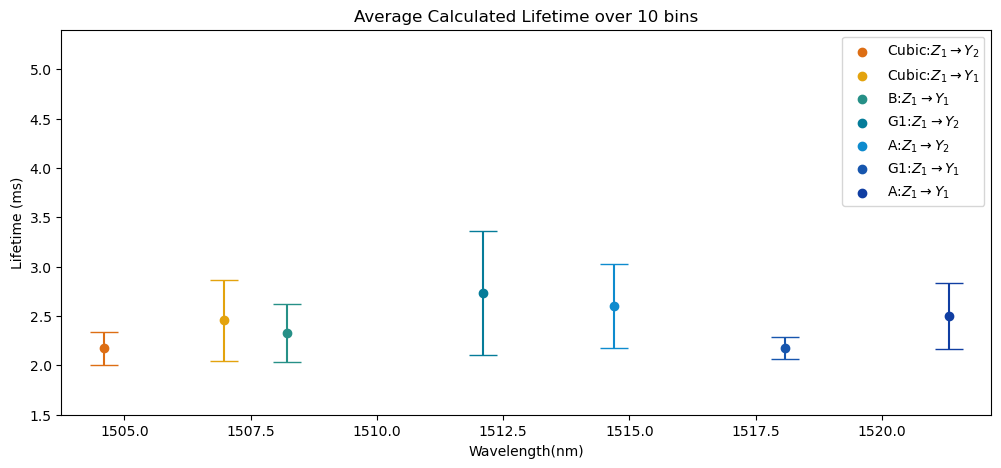

In [426]:
plt.figure(figsize = (12, 5))
for i, col in enumerate(cols):
    plt.scatter(np.mean(wavelengths_1018[:, i]), np.mean(lifetimes_1018[:, i]), 
                color = cols[i],
                label = fr'{linesLabel[i]}')
    plt.errorbar(np.mean(wavelengths_1018[:, i]), np.mean(lifetimes_1018[:, i]), yerr = np.mean(np.abs(lifetimeErrors_1018[:, i])), xerr = None, 
                fmt = 'none', capsize = 10, c = cols[i])

plt.xlabel('Wavelength(nm)')
plt.ylabel('Lifetime (ms)')
plt.ylim([1.5, 5.4])
plt.legend(loc = 'upper right')
plt.title(f'Average Calculated Lifetime over {numBins} bins')
plt.show()

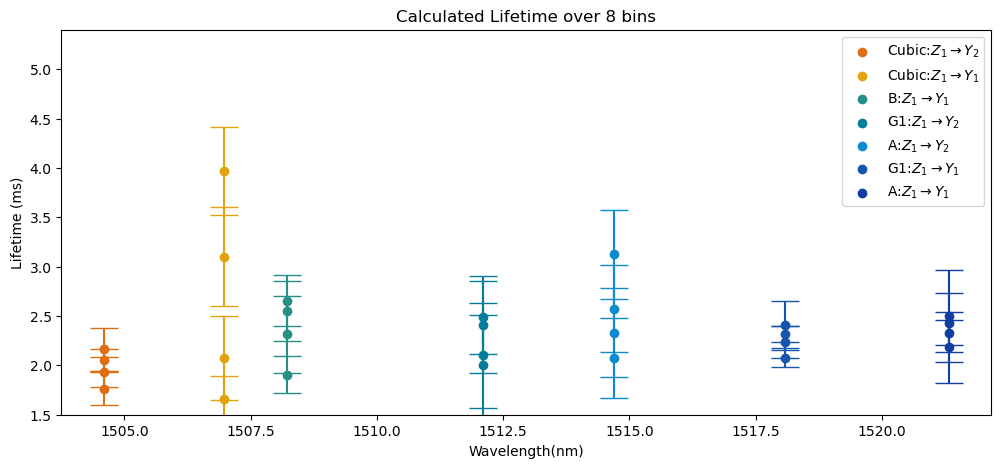

In [ ]:
numBins = 8

wavelengths_1018, lifetimes_1018, lifetimeErrors_1018 = plot_time_traces(folderPath = folders_1018,
                    numBins = numBins,
                    choose = choose,
                    save = False,
                    cols = cols,
                    savePath = folders_1018, 
                    plot = False)

plt.figure(figsize = (12, 5))
for i, col in enumerate(cols):
    plt.scatter(wavelengths_1018[:, i], lifetimes_1018[:, i], 
                color = cols[i],
                label = fr'{linesLabel[i]}')
    plt.errorbar(wavelengths_1018[:, i], lifetimes_1018[:, i], yerr = np.abs(lifetimeErrors_1018[:, i]), xerr = None, 
                fmt = 'none', capsize = 10, c = cols[i])

plt.xlabel('Wavelength(nm)')
plt.ylabel('Lifetime (ms)')
plt.ylim([1.5, 5.4])
plt.legend(loc = 'upper right')
plt.title(f'Calculated Lifetime over {numBins} bins')
plt.show()

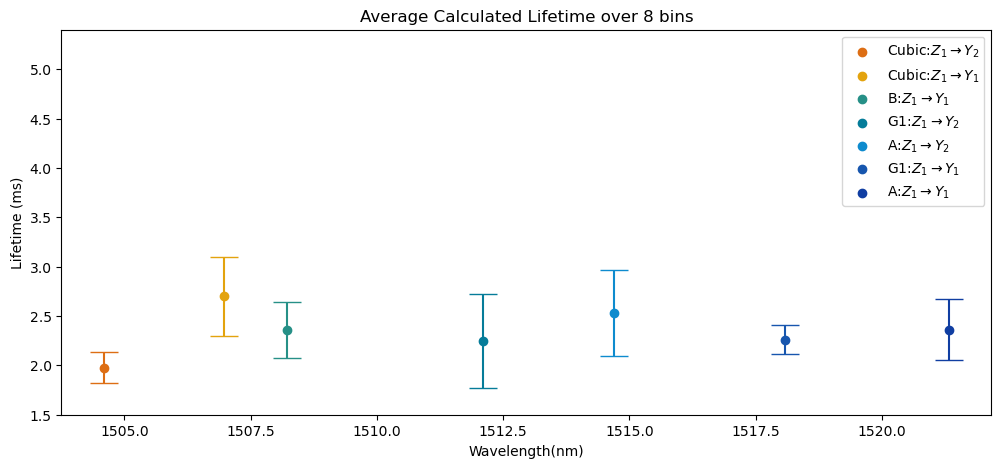

In [423]:
plt.figure(figsize = (12, 5))
for i, col in enumerate(cols):
    plt.scatter(np.mean(wavelengths_1018[:, i]), np.mean(lifetimes_1018[:, i]), 
                color = cols[i],
                label = fr'{linesLabel[i]}')
    plt.errorbar(np.mean(wavelengths_1018[:, i]), np.mean(lifetimes_1018[:, i]), yerr = np.mean(np.abs(lifetimeErrors_1018[:, i])), xerr = None, 
                fmt = 'none', capsize = 10, c = cols[i])

plt.xlabel('Wavelength(nm)')
plt.ylabel('Lifetime (ms)')
plt.ylim([1.5, 5.4])
plt.legend(loc = 'upper right')
plt.title(f'Average Calculated Lifetime over {numBins} bins')
plt.show()

### 2025-10-25: Function approach

In [129]:
folders_1025 = (glob.glob('data/2025-10-25/*'))
print(folders_1025)

['data/2025-10-25/1518.08', 'data/2025-10-25/1514.7', 'data/2025-10-25/1504.59024', 'data/2025-10-25/1521.33084', 'data/2025-10-25/1512.10873', 'data/2025-10-25/1506.976', 'data/2025-10-25/1508.22566']


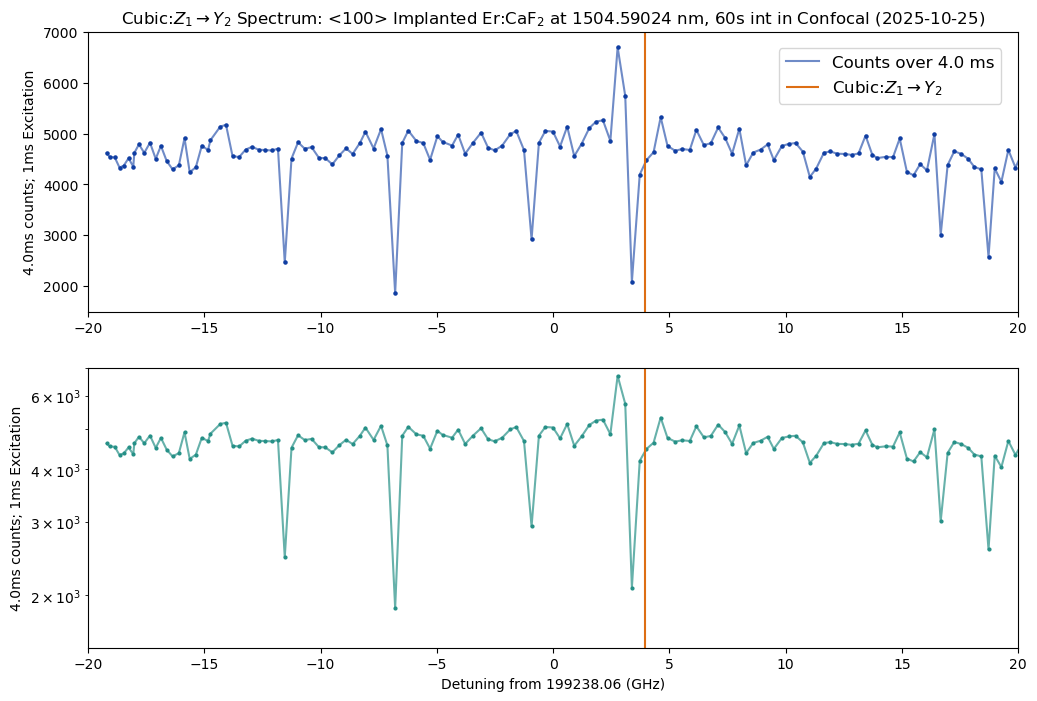

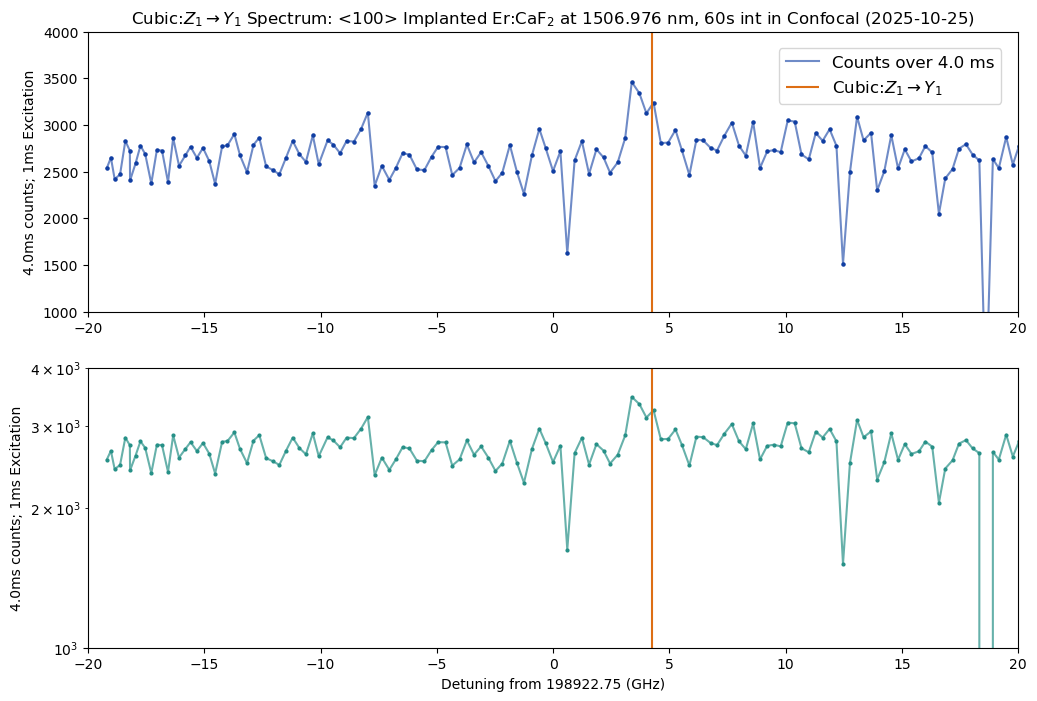

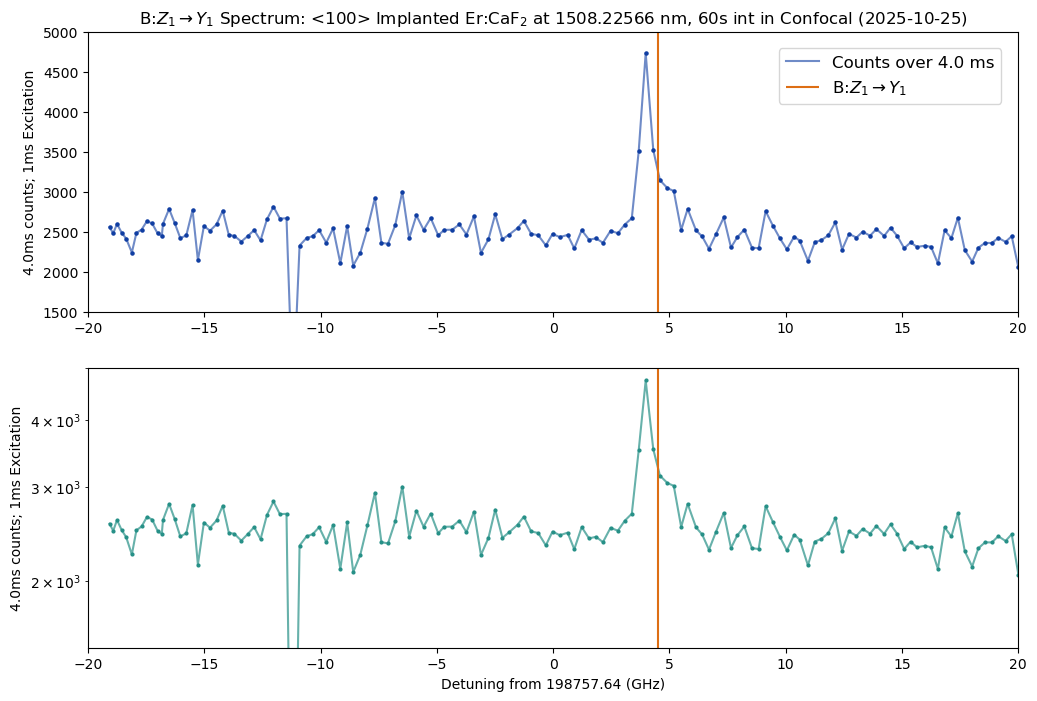

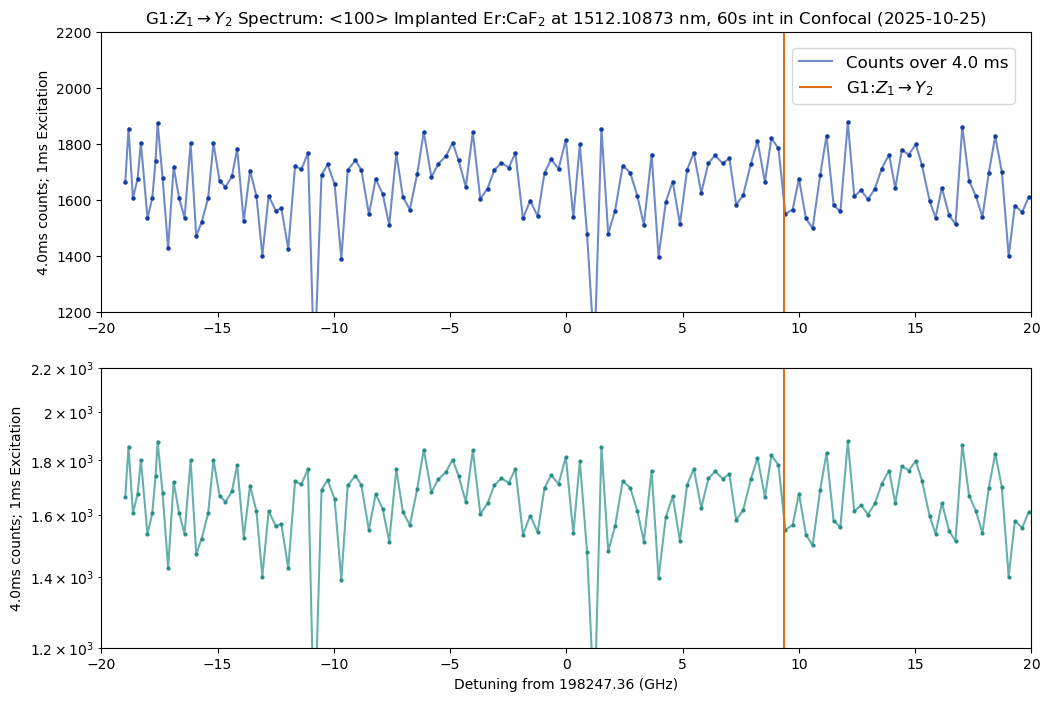

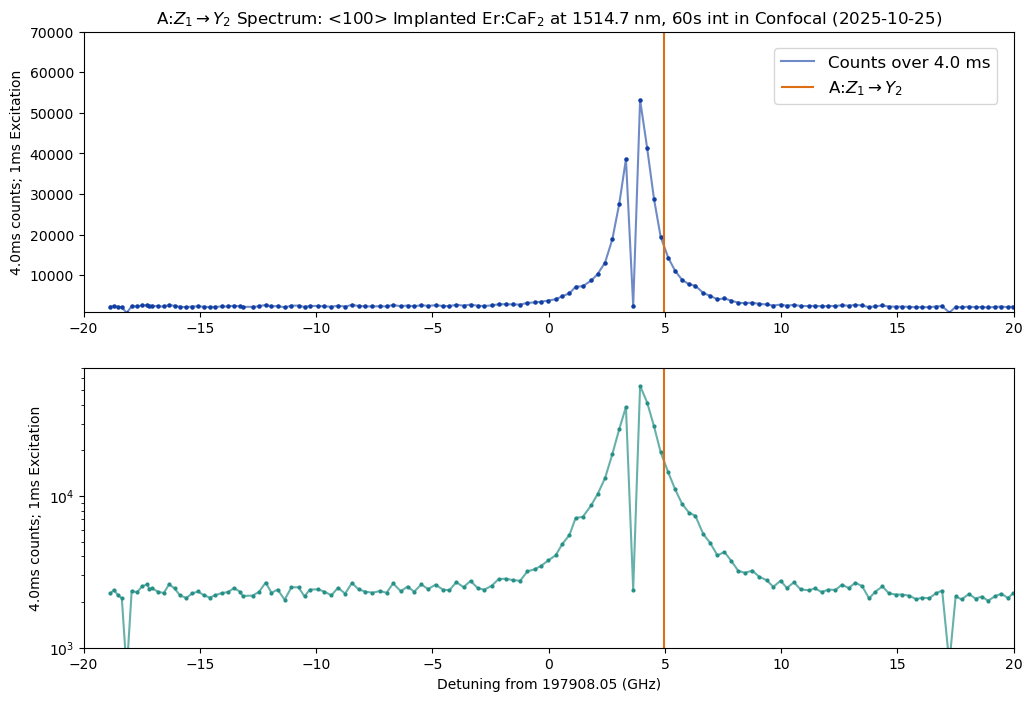

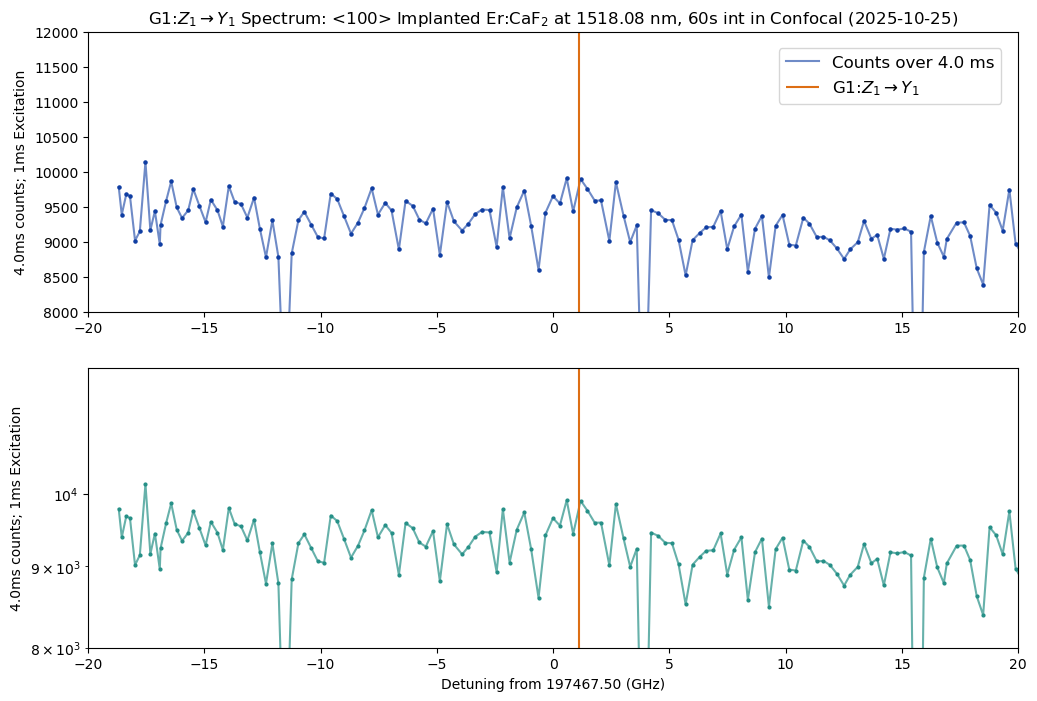

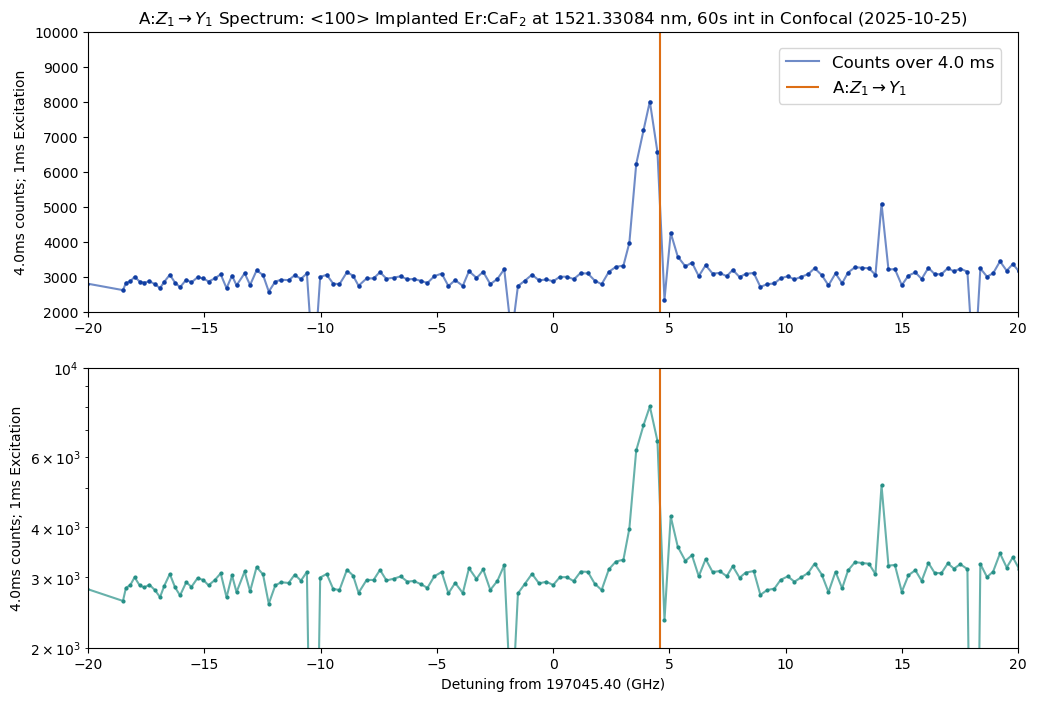

In [408]:
ylims_1025 = [[1.5e3, 7e3],
        [1e3, 4e3],
        [1.5e3, 5e3],
        [1.2e3, 2.2e3],
        [1e3, 7e4],
        [8e3, 12e3],
        [2e3, 1e4]]

fVp_1025 = plot_spectra(
    folderPath = folders_1025,
    numBins = 8,
    intTime = intTime,
    excTime = excTime,
    lines = lines,
    linesLabel = linesLabel,
    ylims = ylims_1025,
    cols = cols,
    save = False,
    savePath = folders_1025)

### Troubleshooting

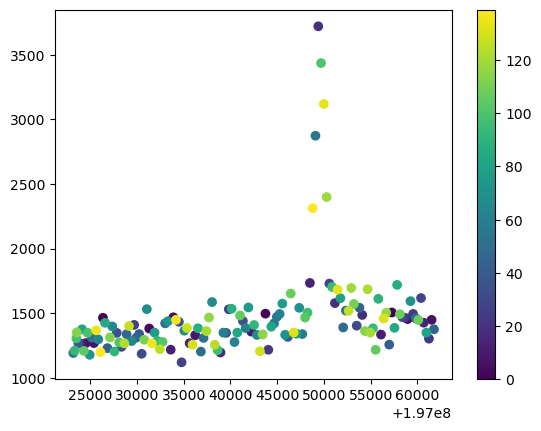

In [65]:
cols = np.arange(len(freqs))
plt.scatter(freqs, peaks, c = cols, cmap = 'viridis')
plt.colorbar()
plt.show()
# so my data are not sequential in frequency?
# need to sort by frequencies before plotting

## Plotting for Tim
Can you make a tiled figure that contains all of them  (including the lack of counts in the G1)? linear y axis is fine, and ideally normalised to the maximum in the largest trace (though i know thats a pain, so absolute number of counts is fine too) - will plot for 10/18

In [123]:
# Directory structure on Angela's mac

# folders_1015 = (glob.glob('data/2025-10-15/*'))
folders_1018 = (glob.glob('data/2025-10-18/*'))
# folders_1025 = (glob.glob('data/2025-10-25/*'))

# sortedFolders_1015 = sorted(folders_1015,
#                        key = lambda x: os.path.basename(x))
sortedFolders_1018 = sorted(folders_1018,
                       key = lambda x: os.path.basename(x))
sortedFolders_1018.remove('data/2025-10-18/1512.10873')  
# sortedFolders_1025 = sorted(folders_1025,
#                        key = lambda x: os.path.basename(x))

# subFolderWavelengths_1015 = [os.path.basename(os.path.normpath(p)) for p in sortedFolders_1015]
subFolderWavelengths_1018 = [os.path.basename(os.path.normpath(p)) for p in sortedFolders_1018]
# subFolderWavelengths_1025 = [os.path.basename(os.path.normpath(p)) for p in sortedFolders_1025]

# folderDates_1015 = [os.path.normpath(p).split(os.sep)[1] for p in sortedFolders_1015]
folderDates_1018 = [os.path.normpath(p).split(os.sep)[1] for p in sortedFolders_1018]
# folderDates_1025 = [os.path.normpath(p).split(os.sep)[1] for p in sortedFolders_1025]

# print(subFolderWavelengths_1015)
# print(sortedFolders_1015)
print(subFolderWavelengths_1018)
print(sortedFolders_1018)
# print(subFolderWavelengths_1025)
# print(sortedFolders_1025)

['1504.59024', '1506.976', '1508.22566', '1514.7', '1518.08', '1521.33084']
['data/2025-10-18/1504.59024', 'data/2025-10-18/1506.976', 'data/2025-10-18/1508.22566', 'data/2025-10-18/1514.7', 'data/2025-10-18/1518.08', 'data/2025-10-18/1521.33084']


In [124]:
# Spectrum Parameters - DOUBLE CHECK
scanHalf = 70       # [V]
n = 140
lineCentre = 70
intTime= 60
excTime = 1
bias = -0.82

In [188]:
# Lines n labels"
lines = [199.242e6, # Cubic Z1-Y2
        198.927e6, # Cubic Z1-Y1  
        198.76215e6, # B Z1-Y1
        # 198.2567e6, # G1 Z1-Y2
        197.913e6, # A Z1-Y2
        197.4686e6, # G1 Z1-Y1
        197.05e6] # A Z1-Y1  

linesLabel = [r'Cubic:$Z_1 \rightarrow Y_2$',
               r'Cubic:$Z_1 \rightarrow Y_1$',
               r'B:$Z_1 \rightarrow Y_1$',
        #        r'G1:$Z_1 \rightarrow Y_2$',
               r'A:$Z_1 \rightarrow Y_2$',
               r'G1:$Z_1 \rightarrow Y_1$',
               r'A:$Z_1 \rightarrow Y_1$']

cols = ['orange', 
        'orange',
        'darkslateblue',
        'orangered',
        'mediumblue',
        'orangered']

ylimsUnNorm_1018 = [[2e3, 9.5e3],
        [1.3e3, 5e3],
        [1.0e3, 7e3],
        # [1e3, 3e3],
        [0.2e3, 1.2e5],
        [7.2e3, 1e4],
        [1.5e3, 17e3]]

ylimsNorm_1018 = [0, 1.1]

numBins = 60

In [126]:
sortedFolders_1018[3]


'data/2025-10-18/1514.7'

In [127]:
# Normalising here, based off max counts on A site
peaks = []
pVs = []
freqs = []

folder = sortedFolders_1018[3]
files = os.listdir(folder)
files = [file for file in files if ".csv" in file]

for file in files:
    fileRead = np.loadtxt(os.path.join(folder, file), delimiter = ",")
    times, data = fileRead[0], fileRead[1]

    counts =  np.sum(data[1:numBins])
    
    # Ignore saturated counts
    if counts > ylimsUnNorm_1018[3][1]:
        counts = 0
    peaks.append(counts)                                                          # add the peak to the list of peaks            


normFactor = max(peaks)
countsNorm = peaks/normFactor

print(normFactor)

81419.0


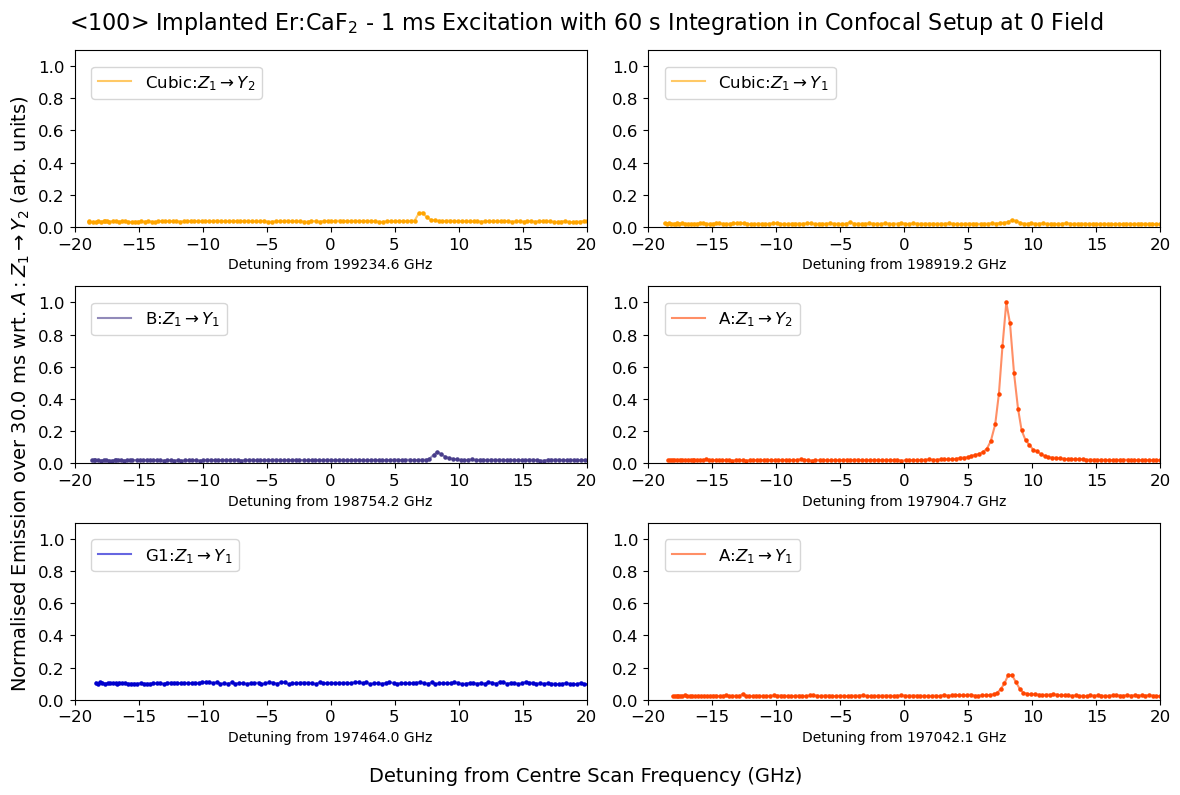

In [254]:
# Plotting 
fig = plt.figure(figsize = (12, 8))
plt.rcParams['xtick.labelsize'] = 12 # Set desired font size globally
plt.rcParams['ytick.labelsize'] = 12 # Set desired font size globally

for i, wave in enumerate(subFolderWavelengths_1018):
    peaks = []
    pVs = []
    freqs = []

    folder = sortedFolders_1018[i]
    files = os.listdir(folder)
    files = [file for file in files if ".csv" in file]

    for file in files:
        fileRead = np.loadtxt(os.path.join(folder, file), delimiter = ",")
        times, data = fileRead[0], fileRead[1]
        timeLimit = times[numBins]
        
        pV = float(file.split("_")[-2])
        freq = float(file.split("_")[2])
        counts =  np.sum(data[1:numBins])
        
        # Ignore saturated counts
        if counts > ylimsUnNorm_1018[i][1]:
            counts = 0
            
        peaks.append(counts)                                                               
        pVs.append(pV)                                                              
        freqs.append(freq)

    peaks = np.array(peaks)
    pVs = np.array(pVs)
    freqs = np.array(freqs)
    
    freqsVpeaks = pd.DataFrame(np.vstack((freqs, peaks))).T # n x 2 array with column 0 = frequencies and column 1 = counts
    freqsVpeaks = freqsVpeaks.rename(columns = {0: r'Frequencies (MHz)', 1: fr'Counts over {timeLimit*1e3} ms'})
    freqsVpeaks = freqsVpeaks.sort_values(by = r'Frequencies (MHz)')
    
    centreFreq = np.mean(freqs) # freqs returns THz
    linesDetuned = (lines[i] - centreFreq)/1e3

    normSpectrum = fig.add_subplot(3, 2, i+1)
    
    # # Plot expected location of lines from onedrive
    # normSpectrum.vlines(linesDetuned, 0, ylimsNorm_1018[1], 
    #         colors = 'k', linestyles = '--', alpha = 0,
    #         label = f'{linesLabel[i]} at {lines[i]/1e6:.2f} THz')
    
    # Plot measured lines, accounting for 400MHz modulation from 2 x 200MHz AOMs
    normSpectrum.scatter((freqsVpeaks[r'Frequencies (MHz)'] - centreFreq + 400) / 1e3, (freqsVpeaks[fr'Counts over {timeLimit*1e3} ms'])/(normFactor), 
                    c = cols[i], s = 5) 
    normSpectrum.plot((freqsVpeaks[r'Frequencies (MHz)'] - centreFreq + 400) / 1e3, (freqsVpeaks[fr'Counts over {timeLimit*1e3} ms'])/(normFactor), 
                c = cols[i], alpha = 0.6, 
                label=f'{linesLabel[i]}')

    normSpectrum.set_xlim([-20, 20])
    normSpectrum.set_xlabel(f'Detuning from {(centreFreq + 400)/1e3 :.1f} GHz')
    normSpectrum.set_ylim([ylimsNorm_1018[0], ylimsNorm_1018[1]])
    normSpectrum.set_yticks(np.arange(0, 1.1, 0.2))
    normSpectrum.legend(fontsize = 12, borderaxespad = 1, loc = 'upper left')
    
    savePath_csv = os.path.join(f'spectrum_{wave}nm.csv')
    save_path_csv = os.path.join(os.path.dirname(sortedFolders_1018[i]), f'spectrum_{wave}nm_{numBins}bins.csv')
    np.savetxt(save_path_csv, freqsVpeaks, delimiter = ',')
    
plt.xticks(fontsize = 12)
fig.supxlabel('Detuning from Centre Scan Frequency (GHz)', fontsize = 14)
fig.supylabel(fr'Normalised Emission over {timeLimit*1e3} ms wrt. $A: Z_1 \rightarrow Y_2$ (arb. units)', fontsize = 14)
plt.suptitle(fr'<100> Implanted Er:CaF$_2$ - 1 ms Excitation with {intTime} s Integration in Confocal Setup at 0 Field', fontsize = 16)

savePath_svg = os.path.join(f'spectrum_{wave}nm.svg')
savePath_svg = os.path.join(os.path.dirname(sortedFolders_1018[i]), f'collated_spectra_{numBins}bins_nlines.svg')  
plt.tight_layout()  
plt.savefig(savePath_svg, dpi = 300, bbox_inches='tight')

plt.show()

In [250]:
freqsVpeaks

,Frequencies (MHz),Counts over 30.0 ms
56,197023187.0,1852.0
93,197023344.0,1824.0
98,197023518.0,1970.0
114,197023561.0,1957.0
38,197023734.0,1829.0
...,...,...
15,197060680.0,2104.0
80,197060966.0,1925.0
22,197061238.0,1857.0
7,197061523.0,2130.0


In [238]:
centreFreq

np.float64(197041680.37857142)